# Incompleteness correction: self-test and diagonal padding

Two experiments built on `TestIncompletenessCorrection`:

1. **Self-test.** Derive the correction from *all* the SV3 rosettes and apply it to those same rosettes.
   The fiberassign catalog is the subset of the no-fiberassign catalog that got fibers, so with no padding and
   no regularization the correction is algebraically exact. Any deviation of corrected / complete from 1
   is therefore **bias the correction itself introduces**: from the diagonal padding and from the rcond
   regularization. (Objects with counts above `MAXCOUNTS` do not bias it: the matrices carry an overflow
   state for them, which is used only to correct the in-range bins and is never plotted or used in a
   moment. See the note at the end.)
2. **Diagonal padding.** Vary the pseudo-count added to each diagonal cell of the summed count matrix
   (default 1; 0 turns it off; non-integer values are fine), in both the self-test and the split-half test.

The self-test measures bias. The split-half test measures how well the correction generalizes to rosettes
it was not built from, which includes the bias plus noise in the matrix. A good padding keeps the
self-test bias small without making the split-half test worse.

In [10]:
import contextlib
import io
from importlib import reload

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

import IncompletenessMatrix as IM
import TestIncompletenessCorrection as TIC
reload(IM)
reload(TIC)

def showFigures(result):
    for path in result['figures'].values():
        display(Image(filename = path))

## 1. Self-test: calibrate and test on all rosettes (default padding of 1)

`run(selftest = True)` writes `figs/inccorrection_*_self.png`. rcond is still chosen by the split-sample scan
*inside* the calibration rosettes (here, all of them), exactly as in the split-half test.

The error bars here are less meaningful than in the split-half test: the matrix and the data come from the
same rosettes, so the sample and incompleteness jackknife errors are correlated, and adding them in quadrature
is only approximate. Look at how far the corrected ratio sits from 1, not at its sigma.

rosettes available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
calibrating on:     [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
testing on:         [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
diagonal padding:   1

choosing rcond within the calibration rosettes (1D):
  ELG counts around ELGs rcond = 1.000e-15  (spl

/global/u1/c/crmiller/CiC/CiCPlot.py:18: RuntimeWarning: invalid value encountered in subtract
  deviations = replicates - fullvalue



how far each ratio sits from 1 on all rosettes (self-test):
  ELG counts around ELGs       uncorrected RMS 0.4676   corrected RMS 0.4090 (worst 1.37e+11 sigma, in a bin holding 2 objects)
  LRG counts around LRGs       uncorrected RMS 0.0256   corrected RMS 0.0004 (worst 0.0294 sigma, in a bin holding 31 objects)
  LRG counts around ELGs       uncorrected RMS 0.1201   corrected RMS 0.0081 (worst 0.124 sigma, in a bin holding 18 objects)
  ELG counts around LRGs       uncorrected RMS 0.2953   corrected RMS 0.1364 (worst 0.419 sigma, in a bin holding 3 objects)
  ELG-centered (bivariate)     uncorrected RMS 0.3706   corrected RMS 0.2882 (worst 0.424 sigma, in a bin holding 4 objects)   [*** 1 NEGATIVE probability bin(s) after correction ***]
  LRG-centered (bivariate)     uncorrected RMS 0.2670   corrected RMS 0.2014 (worst 0.242 sigma, in a bin holding 2 objects)   [*** 1 NEGATIVE probability bin(s) after correction ***]

simple moments of the bivariate distribution on all rosettes (se

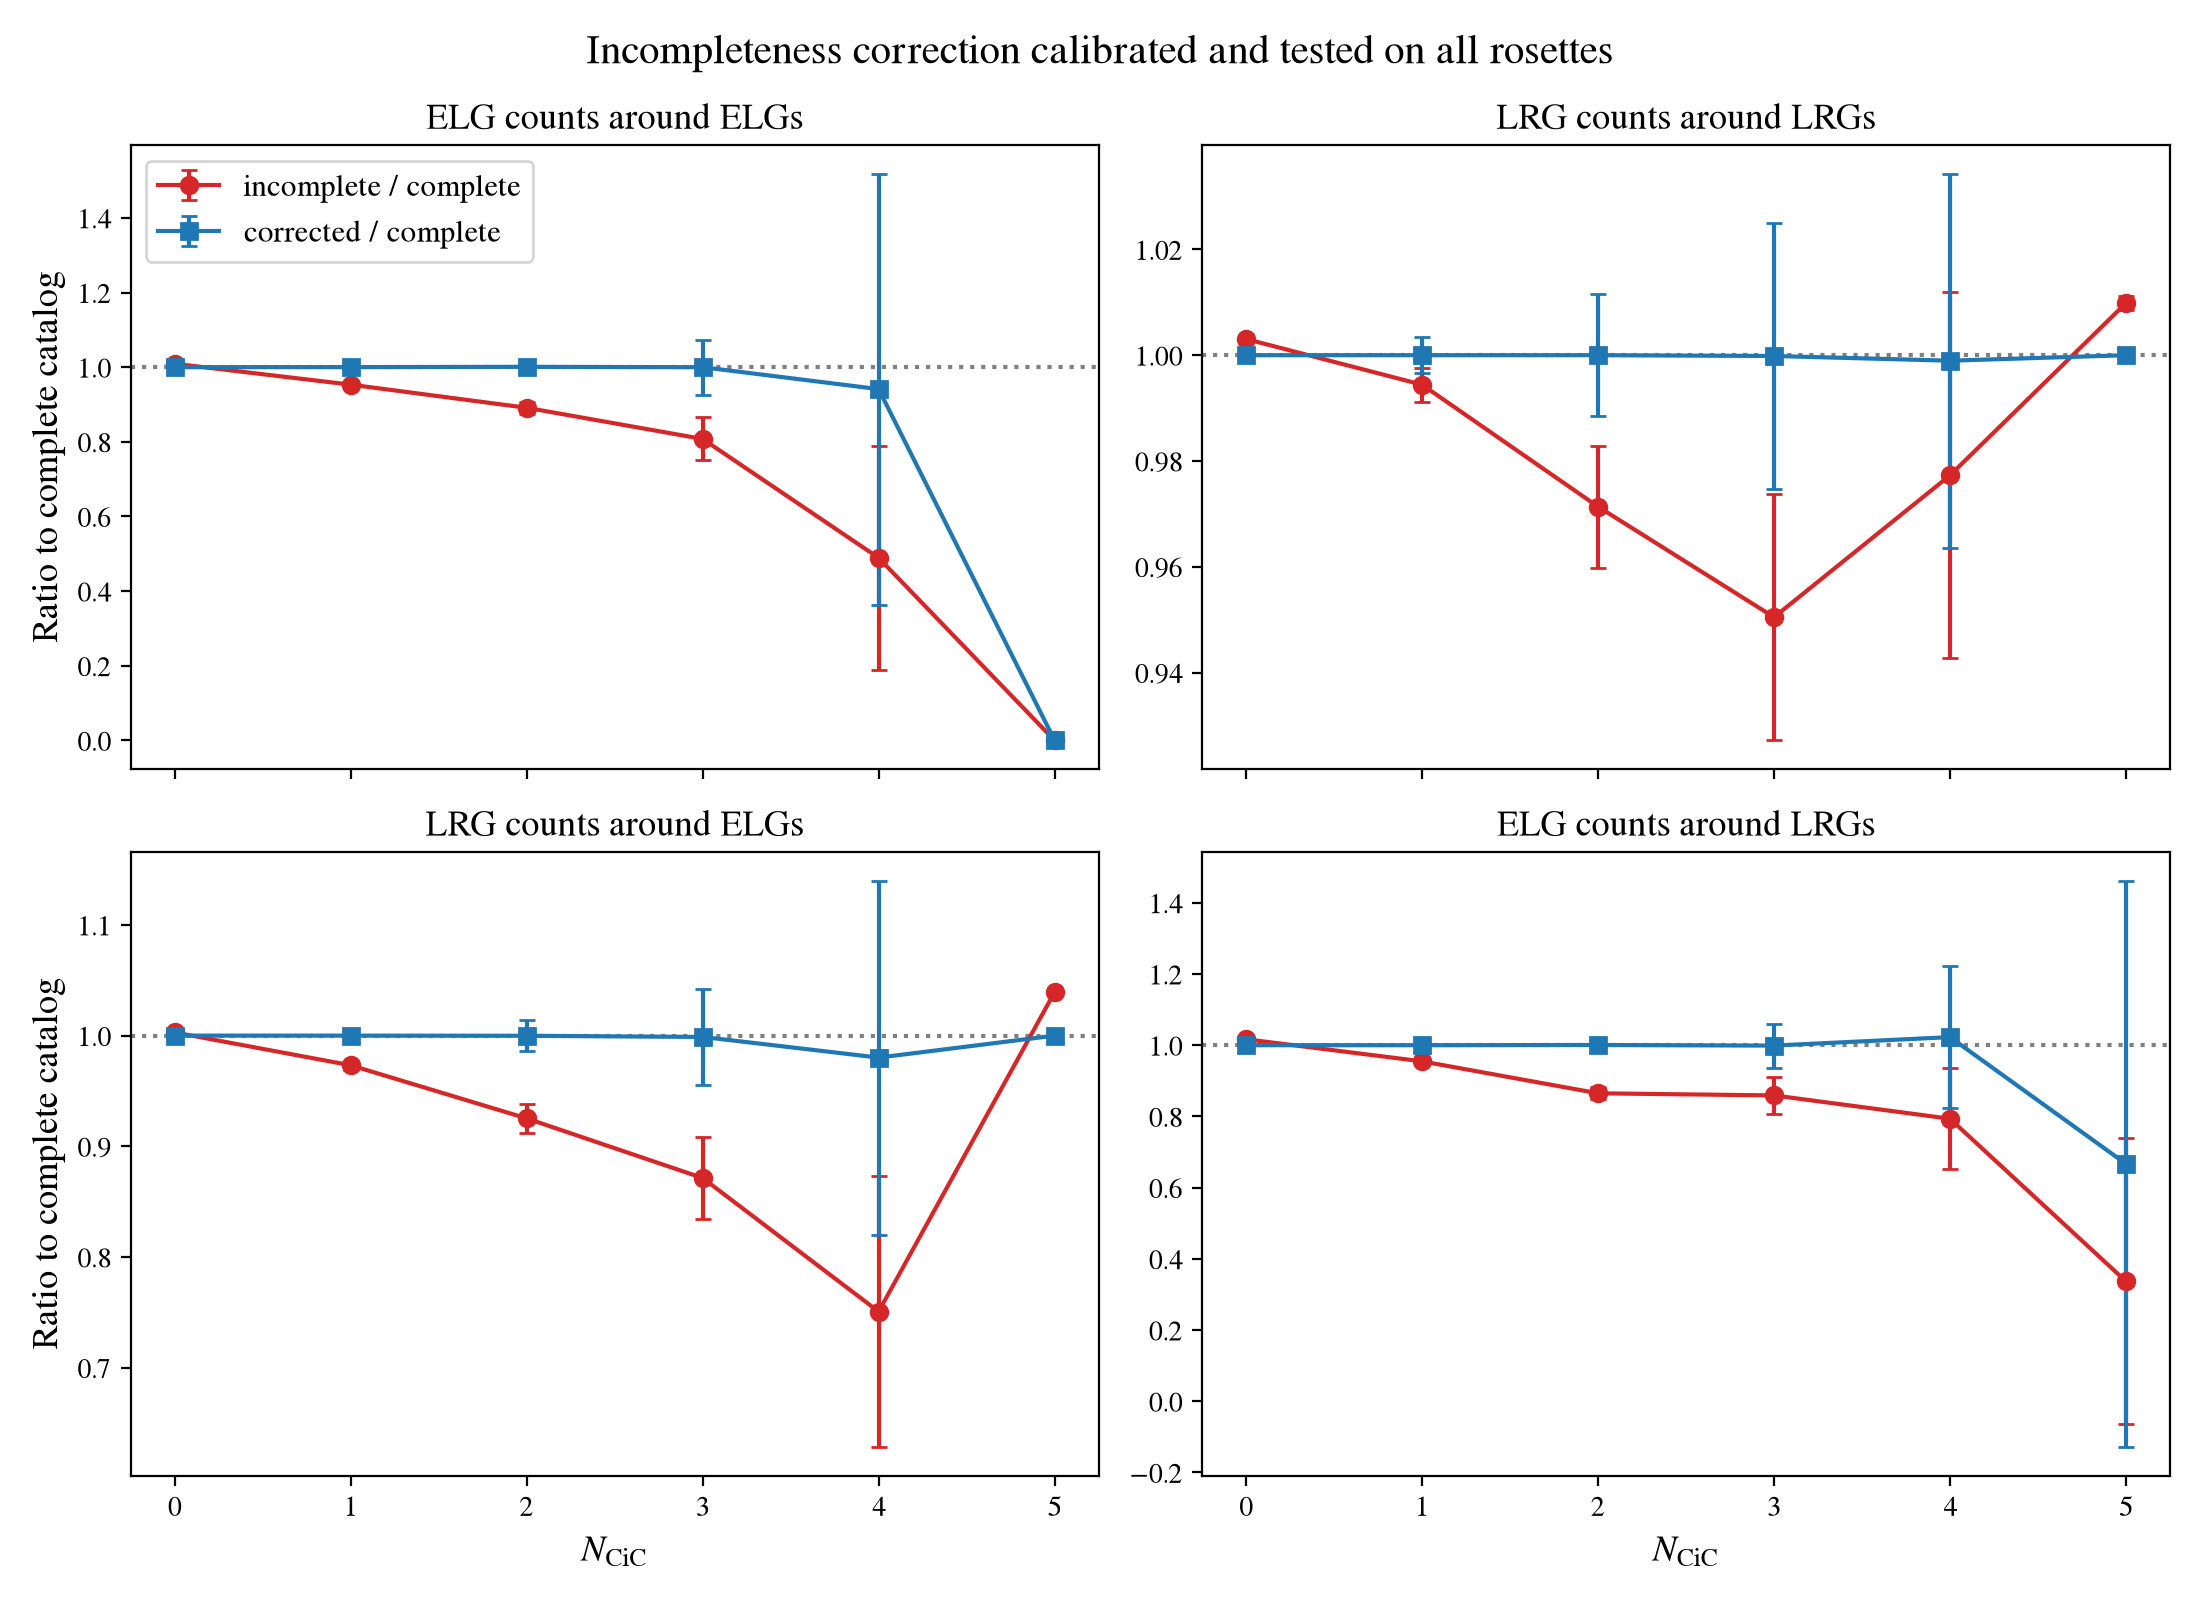

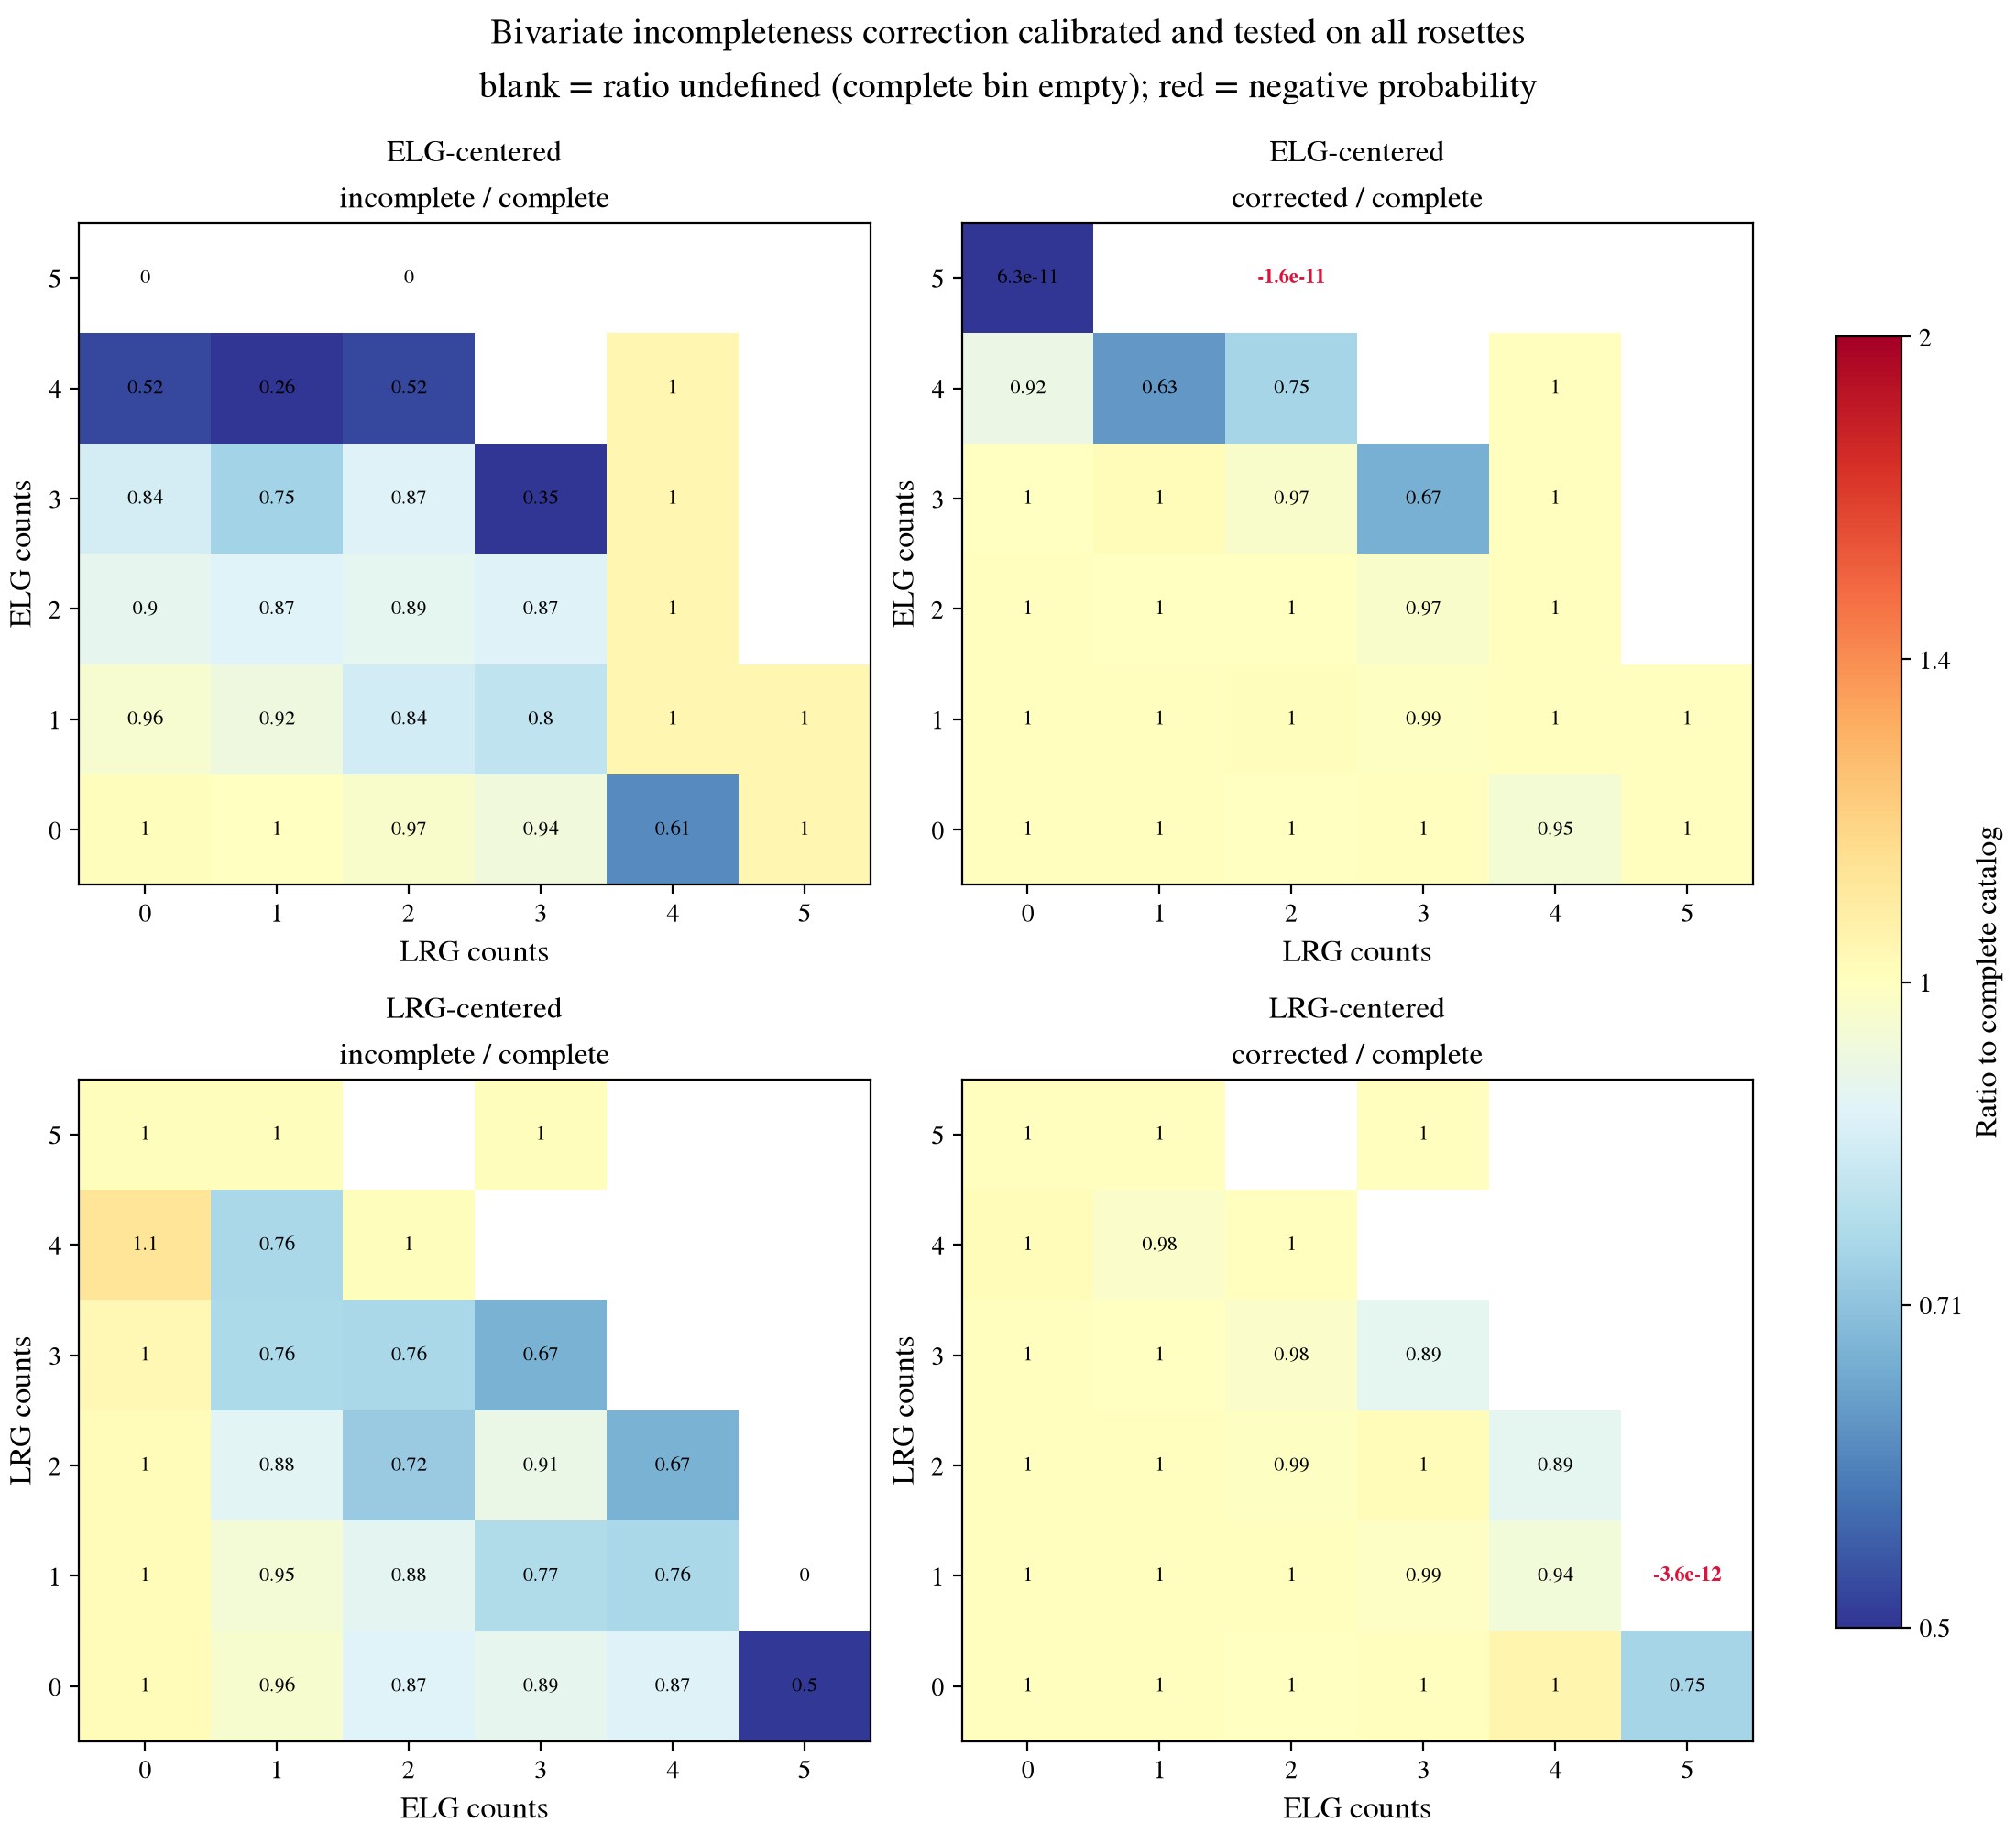

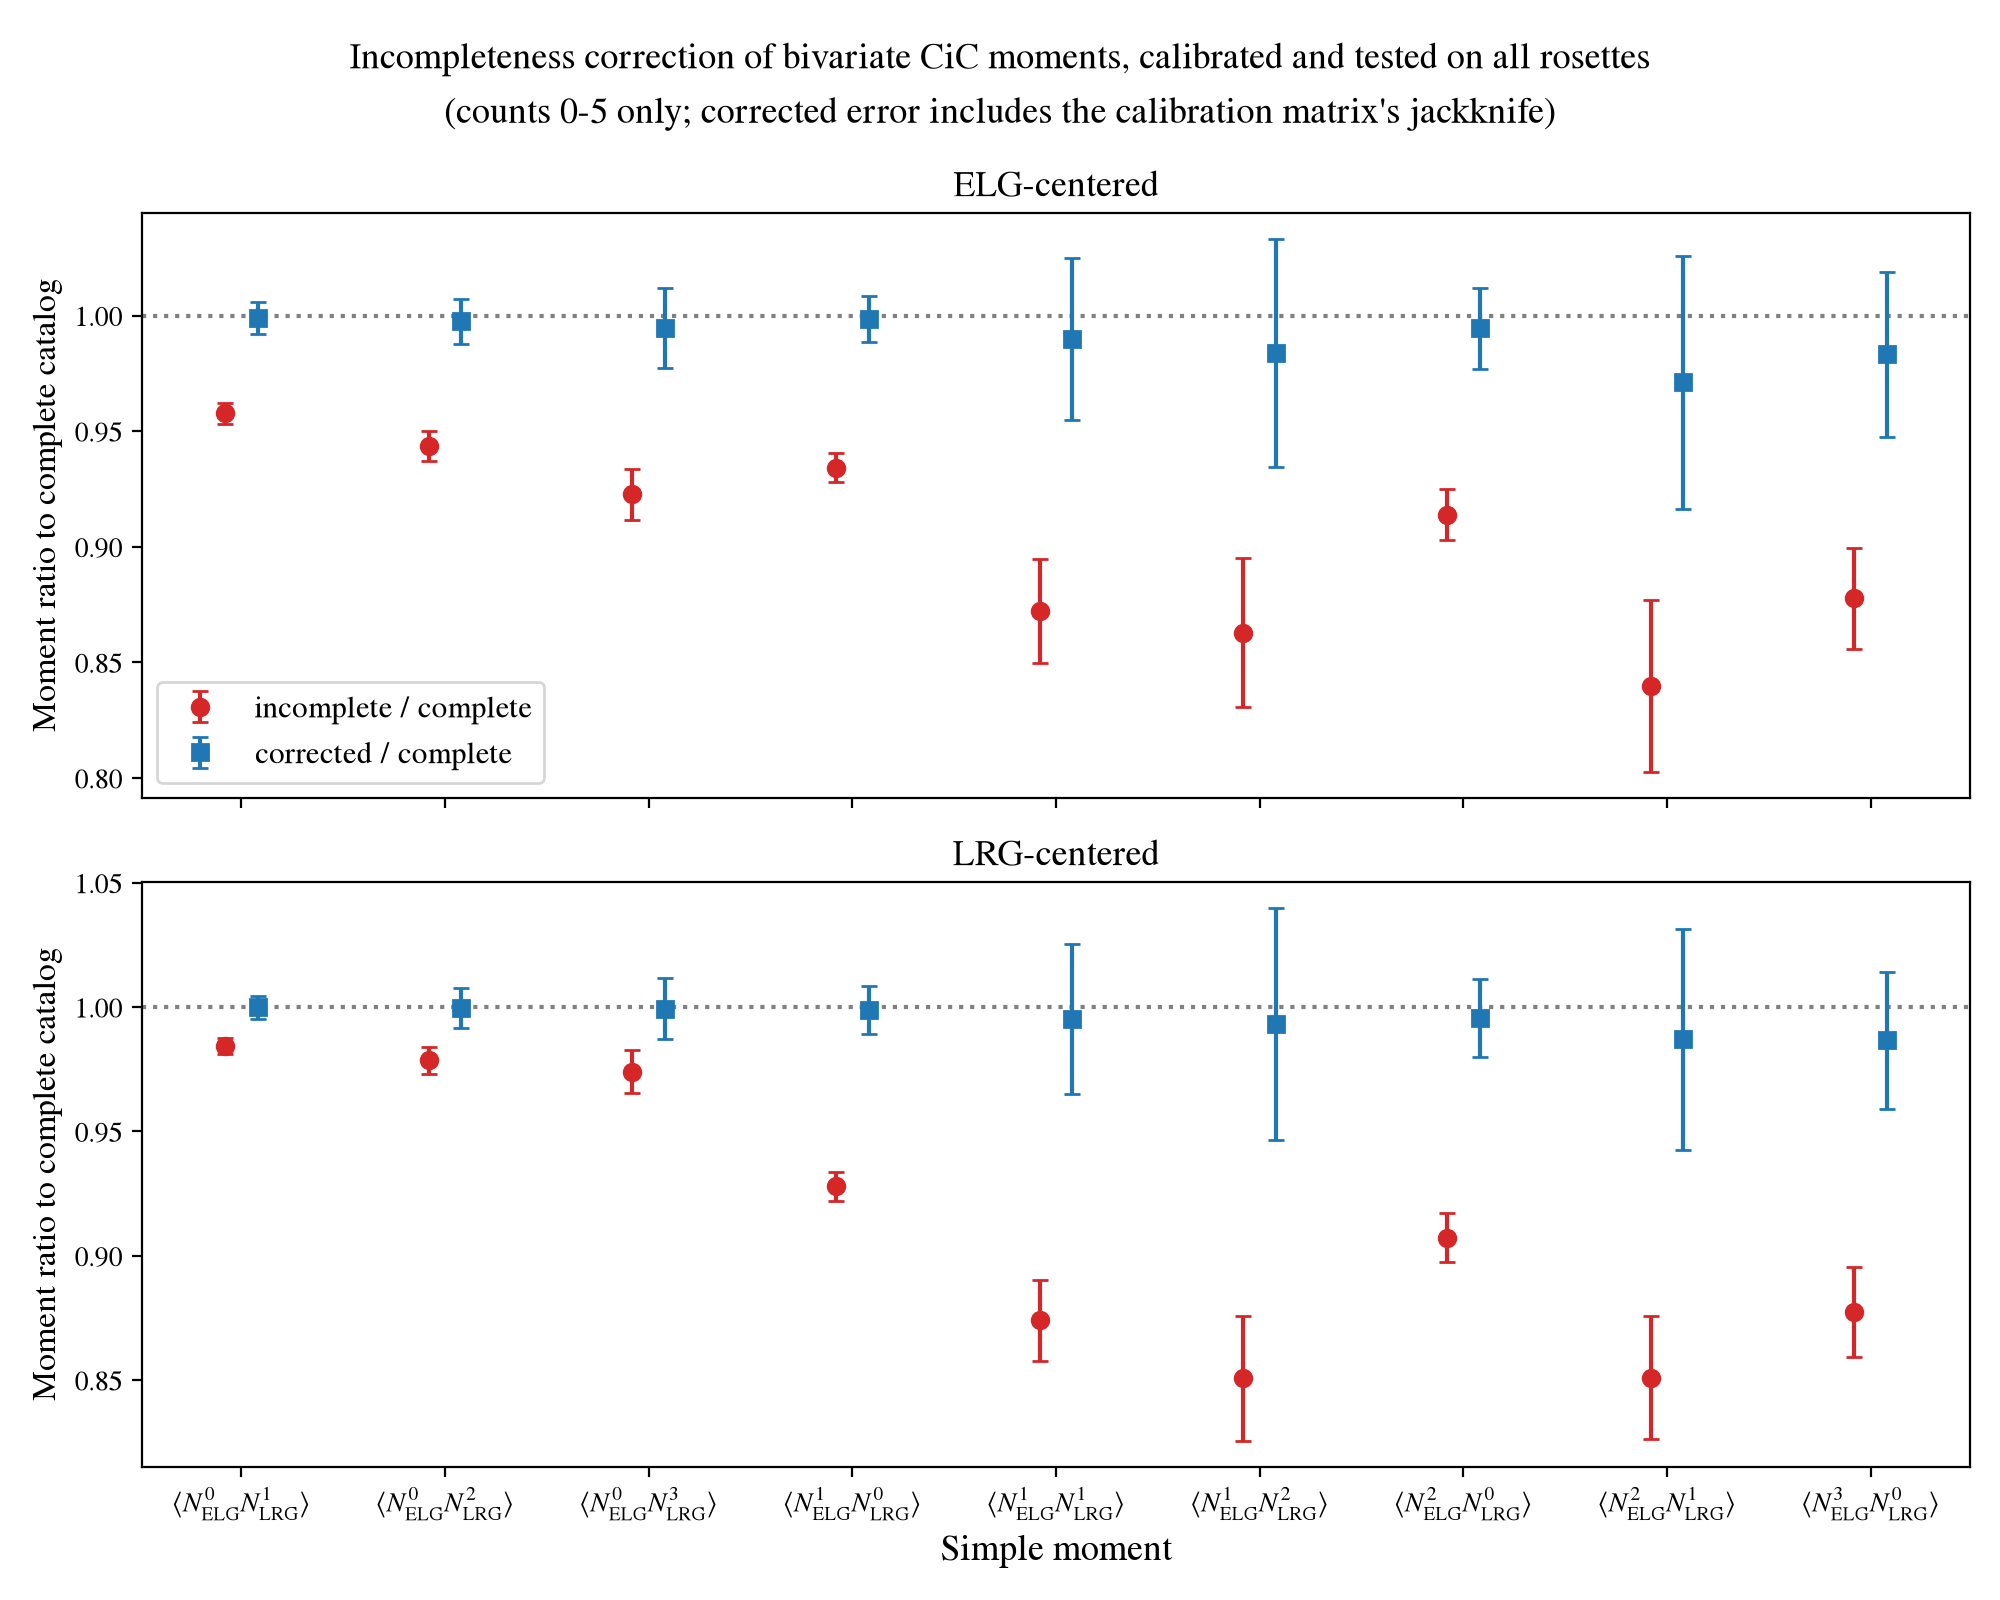

In [11]:
selfresult = TIC.run(selftest = True)
showFigures(selfresult)

For comparison, the usual split-half test with the same (default) padding:

rosettes available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
calibrating on:     [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
testing on:         [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
diagonal padding:   1

choosing rcond within the calibration rosettes (1D):
  ELG counts around ELGs rcond = 1.000e-15  (split-sample RMS corrected/true - 1 = 0.0561; worst in scan 0.0561)
    NOTE: the optimum is at the low end of the scanned range. Either no regularization is needed (low end) or the range does not reach far enough -- widen RCONDVALUES and rerun to be sure.
  LRG counts arou

/global/u1/c/crmiller/CiC/CiCPlot.py:18: RuntimeWarning: invalid value encountered in subtract
  deviations = replicates - fullvalue


  LRG-centered   rcond = 1.000e-15  (split-sample RMS corrected/true - 1 = 0.2738; worst in scan 0.2738)
    NOTE: the optimum is at the low end of the scanned range. Either no regularization is needed (low end) or the range does not reach far enough -- widen RCONDVALUES and rerun to be sure.
Note: 1 of 13406 primaries (0.00746%) have counts above the matrix range (0..5); they are used only to correct the in-range bins and never enter a moment

how far each ratio sits from 1 on the held-out half:
  ELG counts around ELGs       uncorrected RMS 0.5096   corrected RMS 0.5050 (worst 2.46 sigma, in a bin holding 89 objects)   [*** 1 NEGATIVE probability bin(s) after correction ***]
  LRG counts around LRGs       uncorrected RMS 0.0275   corrected RMS 0.0259 (worst 23.1 sigma, in a bin holding 14 objects)
  LRG counts around ELGs       uncorrected RMS 0.1482   corrected RMS 0.0994 (worst 3.16 sigma, in a bin holding 2796 objects)
  ELG counts around LRGs       uncorrected RMS 0.4270   correc

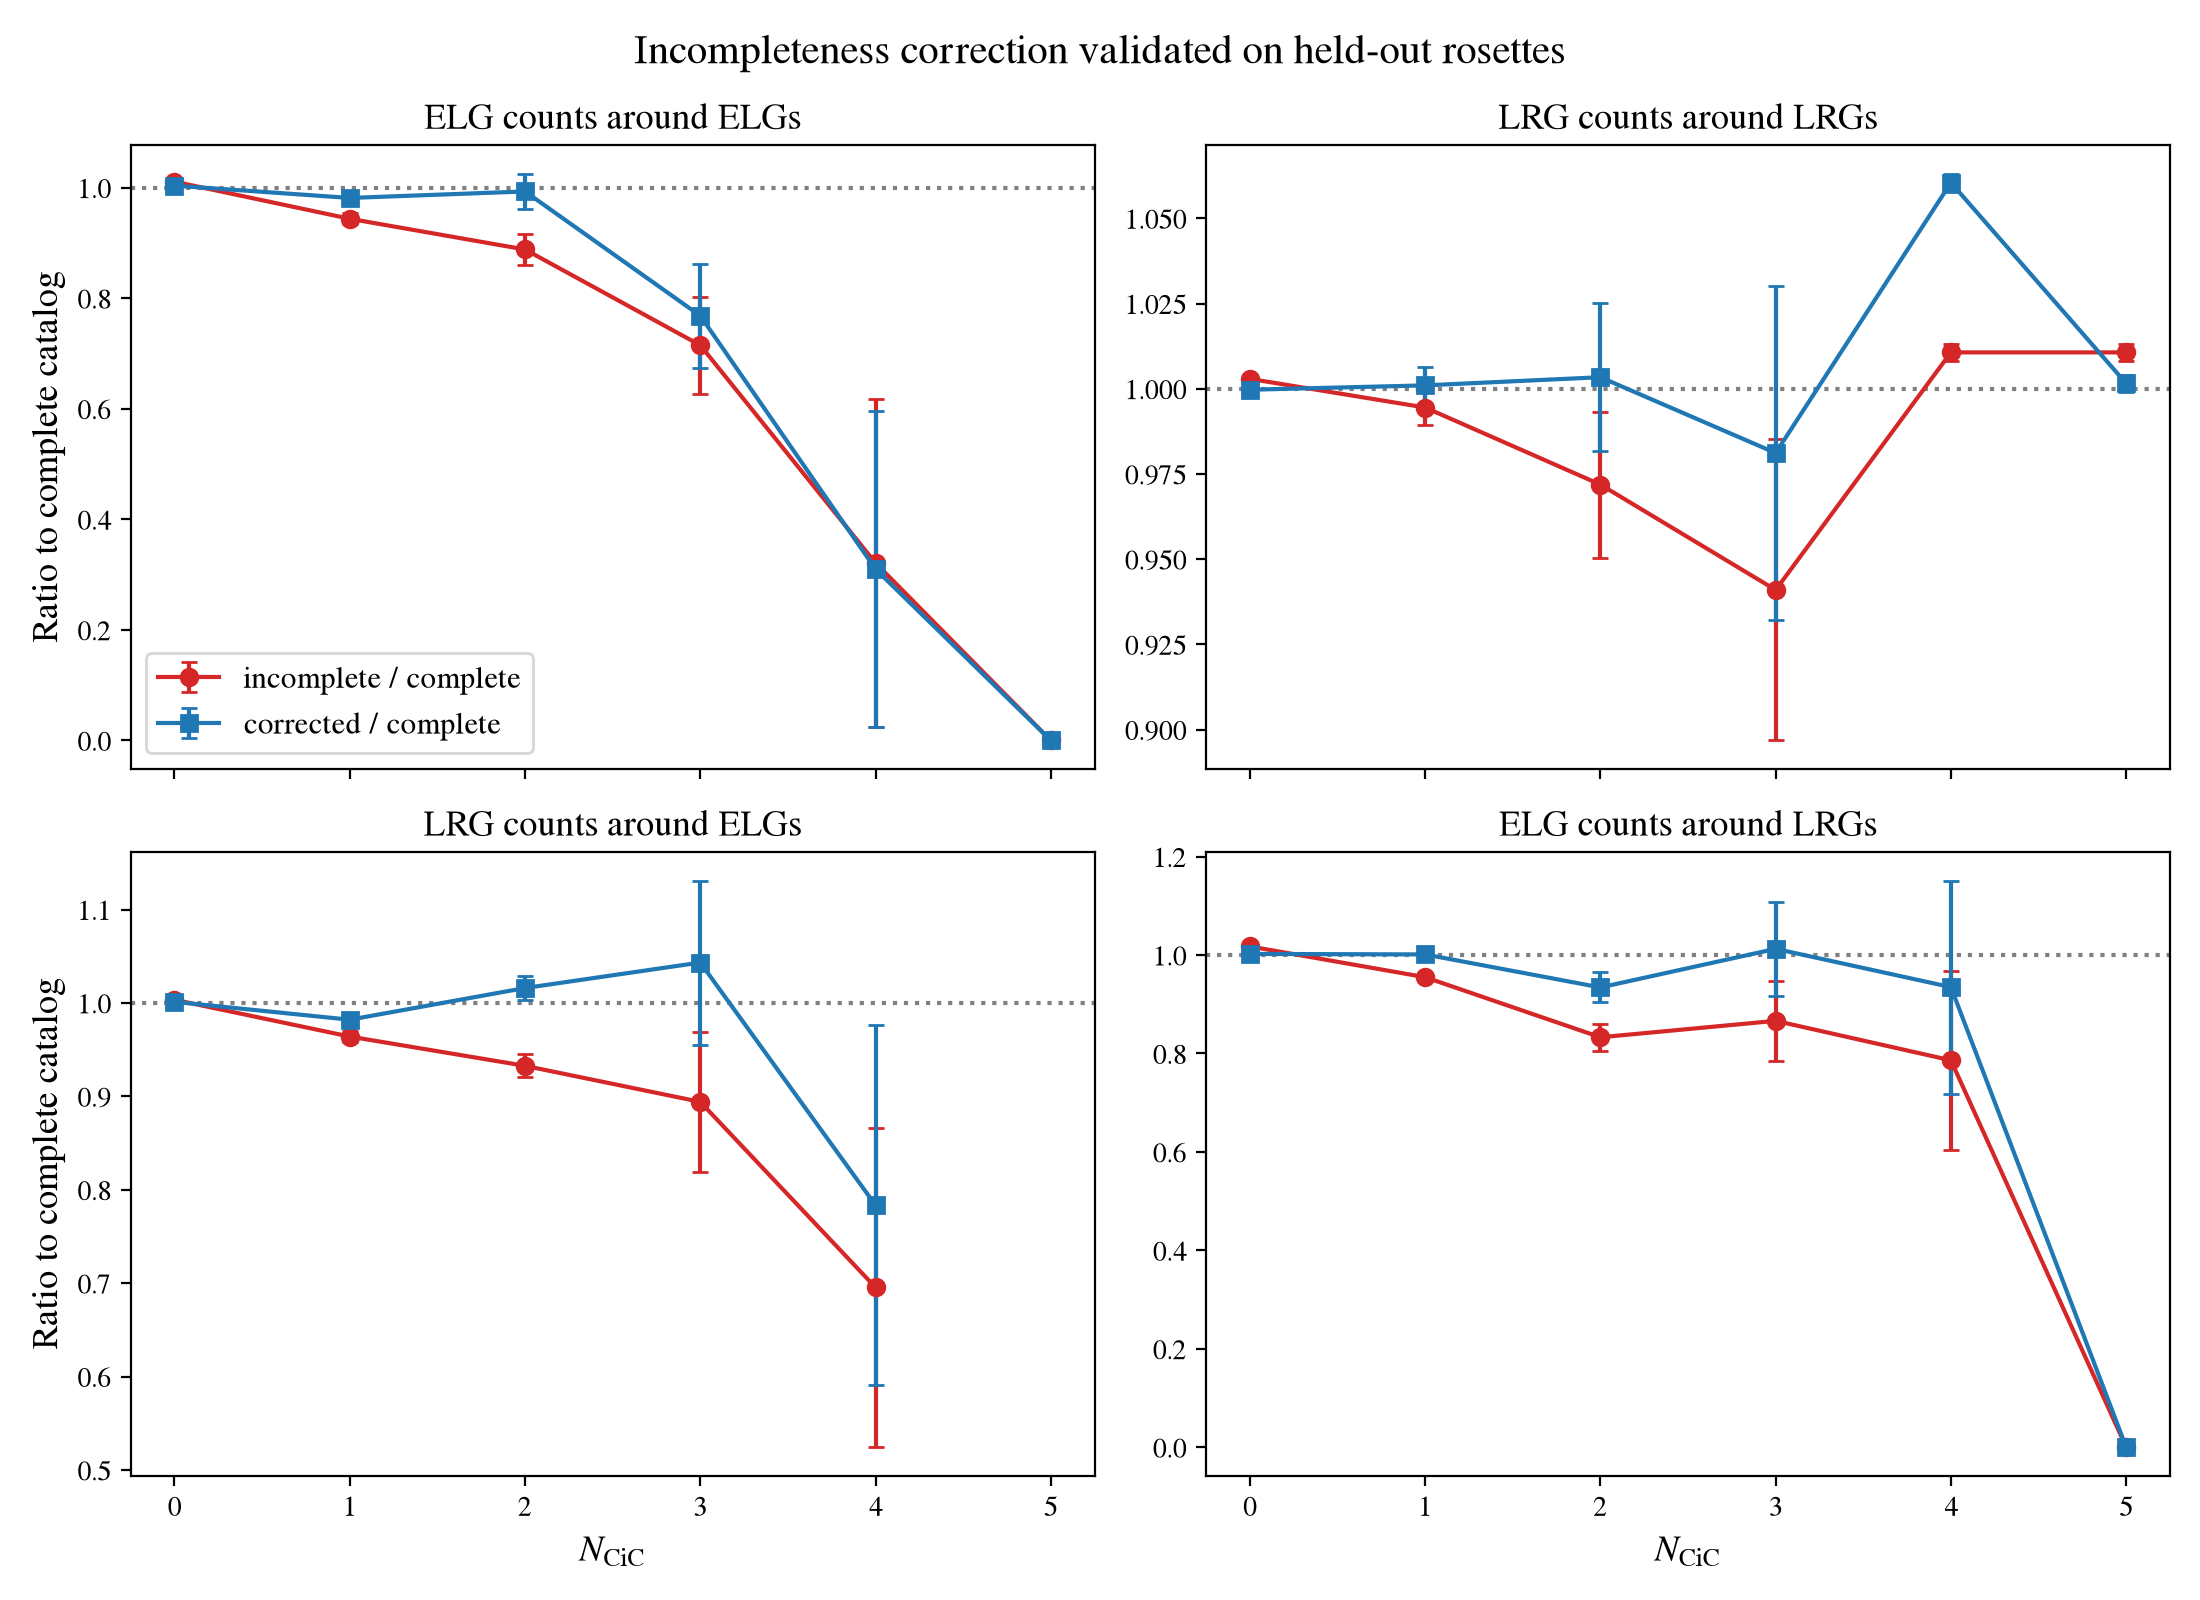

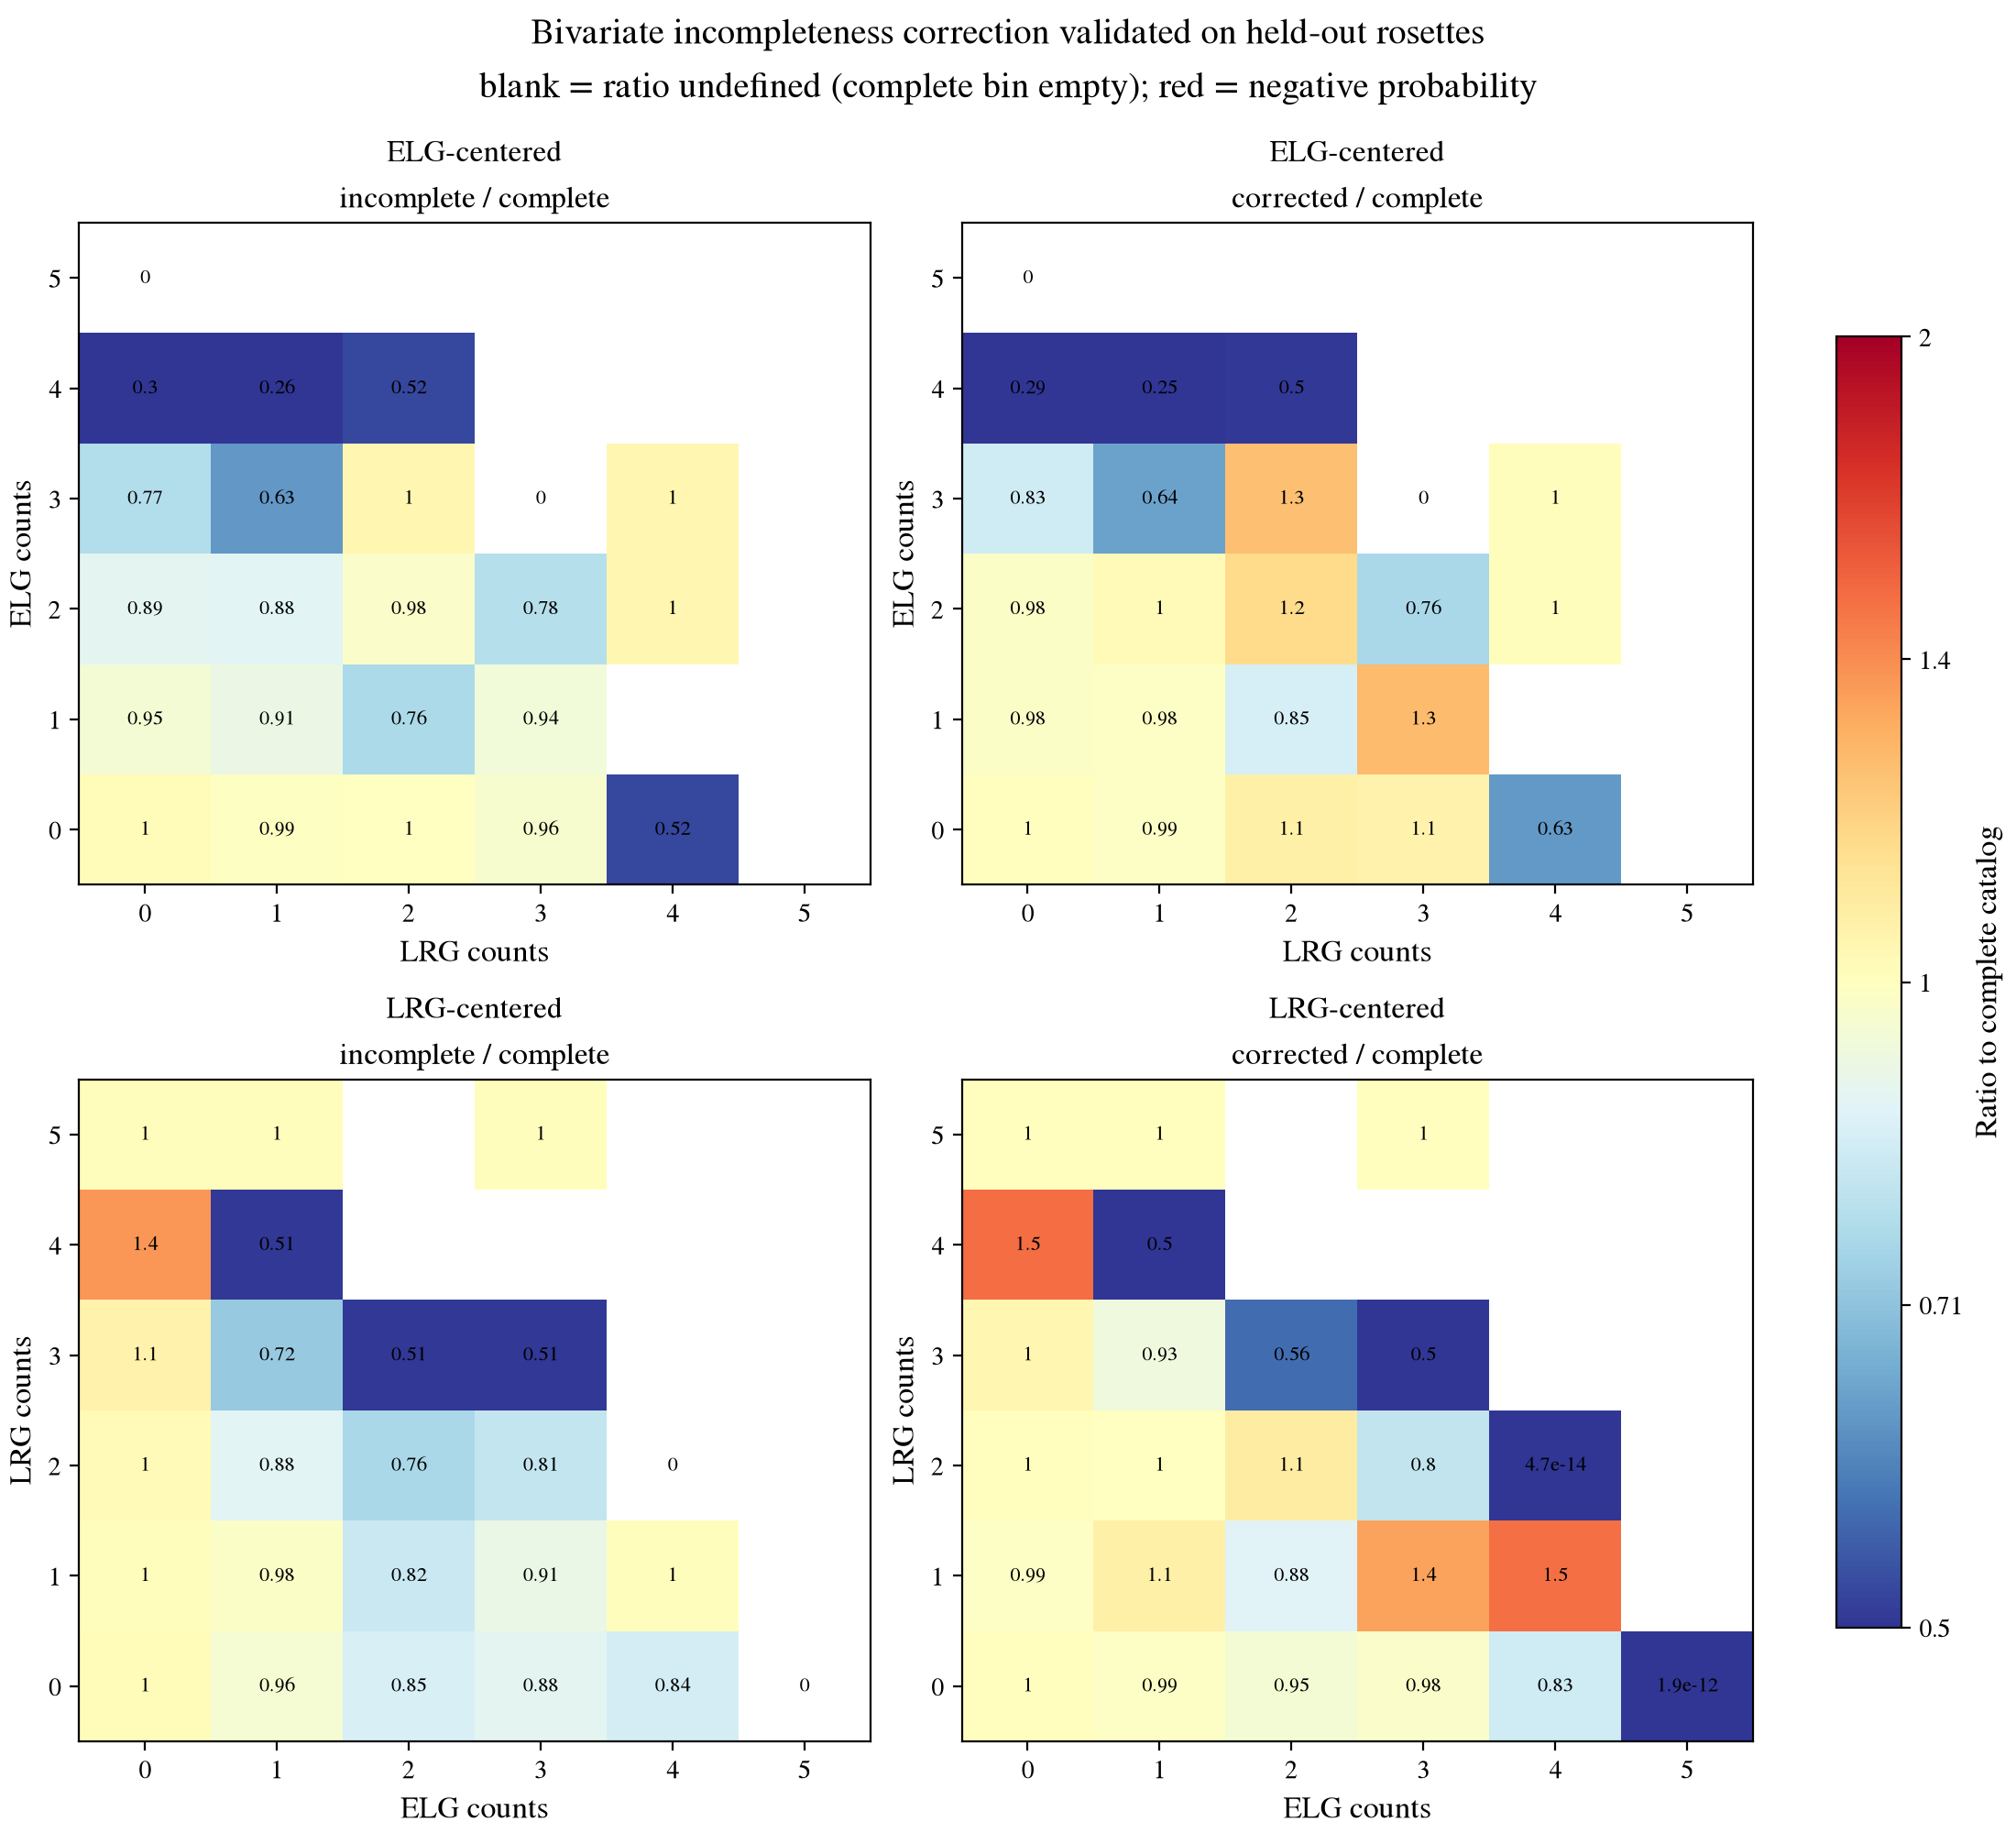

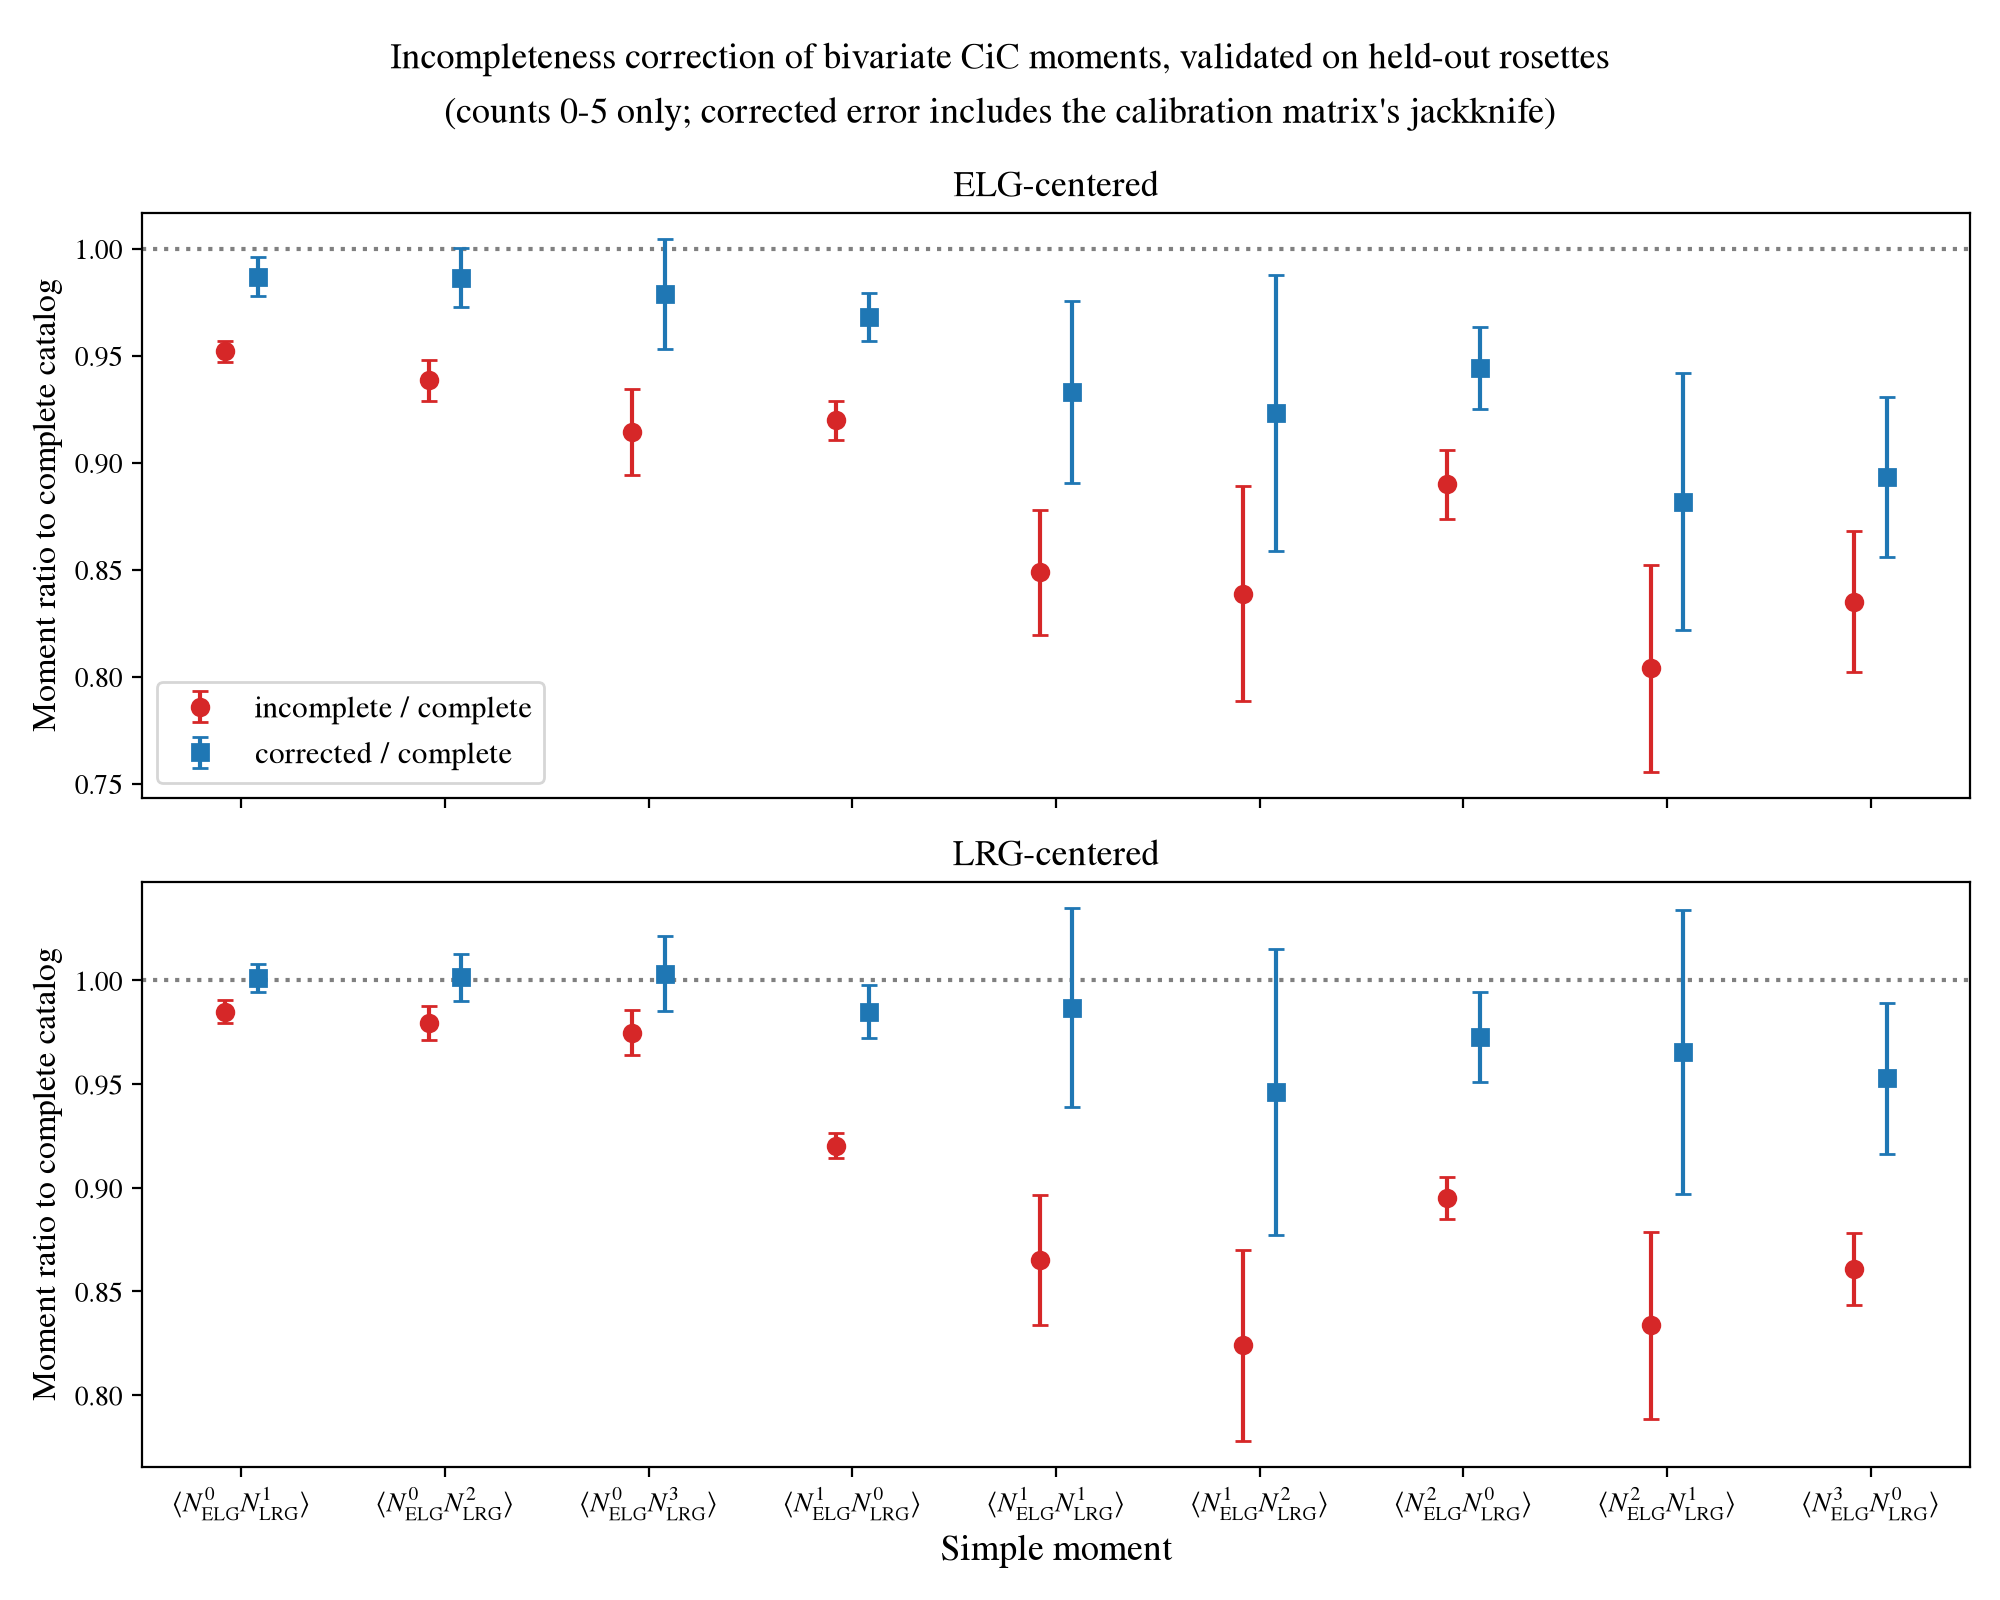

rosettes available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
calibrating on:     [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
testing on:         [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
diagonal padding:   1

choosing rcond within the calibration rosettes (1D):
  ELG counts around ELGs rcond = 1.000e-15  (split-sample RMS corrected/true - 1 = 1.8164; worst in scan 28.3347)
    NOTE: the optimum is at the low end of the scanned range. Either no regularization is needed (low end) or the range does not reach far enough -- widen RCONDVALUES and rerun to be sure.
  LRG counts aro

/global/u1/c/crmiller/CiC/CiCPlot.py:18: RuntimeWarning: invalid value encountered in subtract
  deviations = replicates - fullvalue


  LRG-centered   rcond = 1.000e-15  (split-sample RMS corrected/true - 1 = 0.6275; worst in scan 0.6275)
    NOTE: the optimum is at the low end of the scanned range. Either no regularization is needed (low end) or the range does not reach far enough -- widen RCONDVALUES and rerun to be sure.
Note: 3 of 14876 primaries (0.0202%) have counts above the matrix range (0..5); they are used only to correct the in-range bins and never enter a moment

how far each ratio sits from 1 on the held-out half:
  ELG counts around ELGs       uncorrected RMS 0.4121   corrected RMS 0.8426 (worst 283 sigma, in a bin holding 4 objects)   [*** 1 NEGATIVE probability bin(s) after correction ***]
  LRG counts around LRGs       uncorrected RMS 0.0300   corrected RMS 0.0255 (worst 1.45 sigma, in a bin holding 10 objects)
  LRG counts around ELGs       uncorrected RMS 0.0898   corrected RMS 0.0815 (worst 3.2 sigma, in a bin holding 2958 objects)
  ELG counts around LRGs       uncorrected RMS 0.2303   corrected 

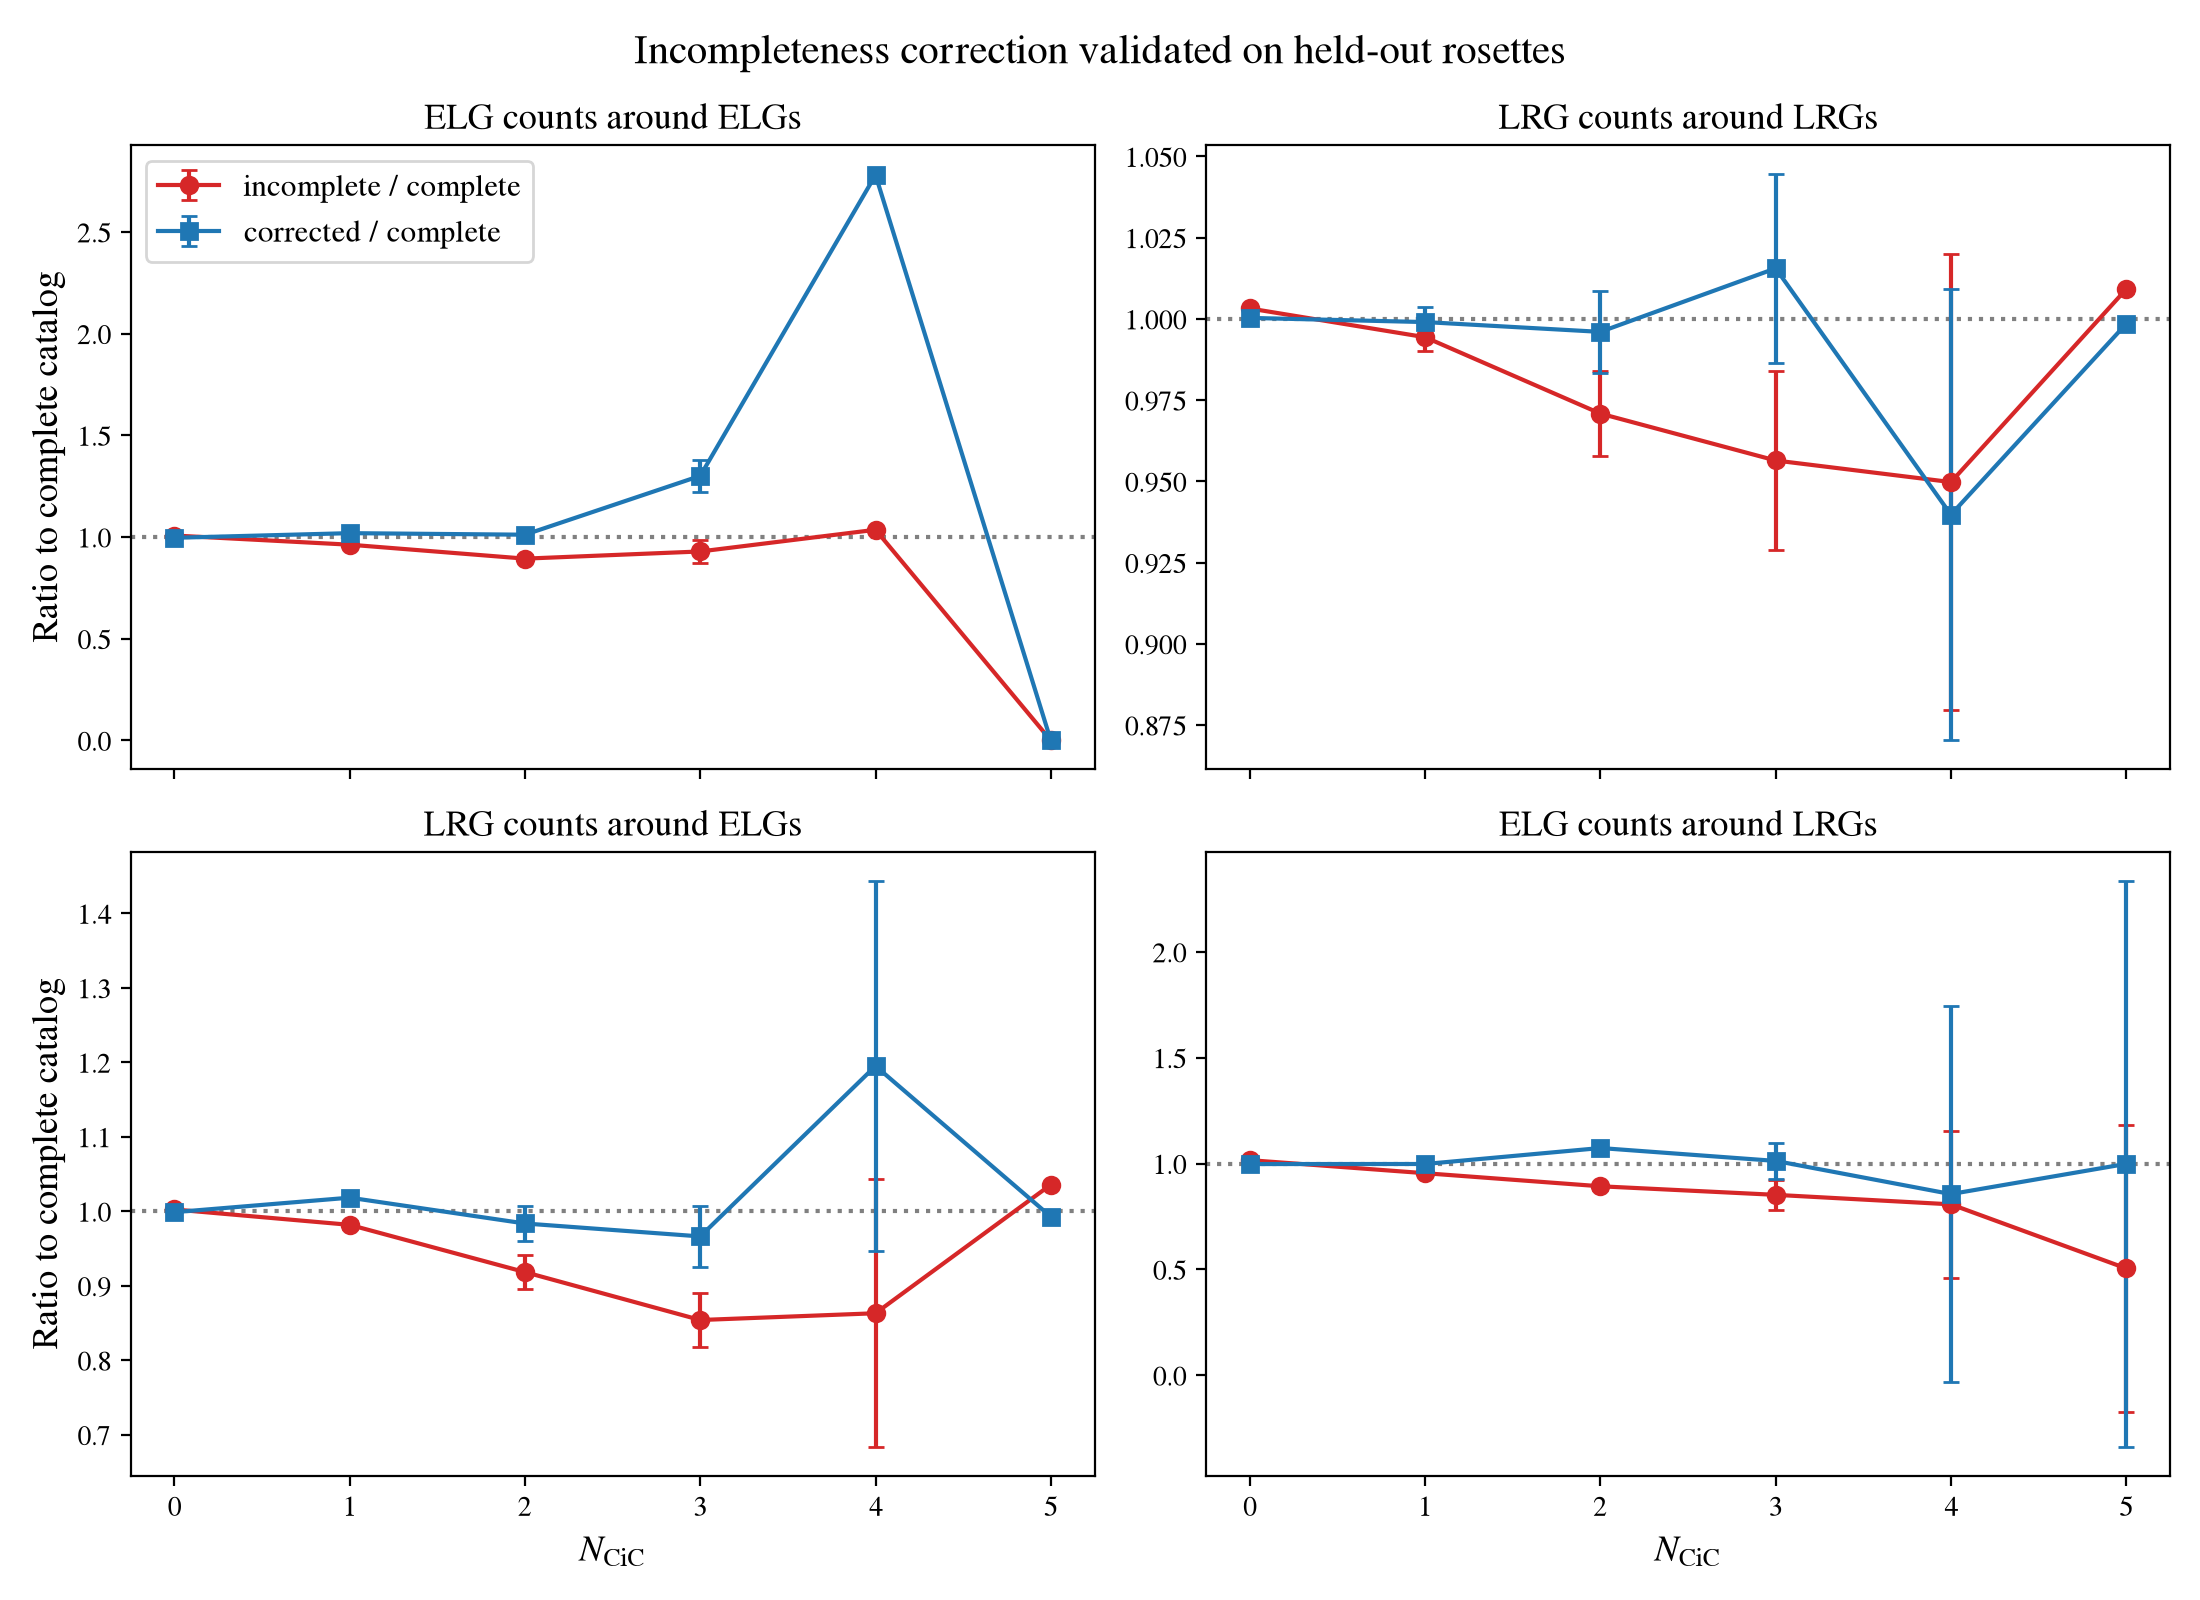

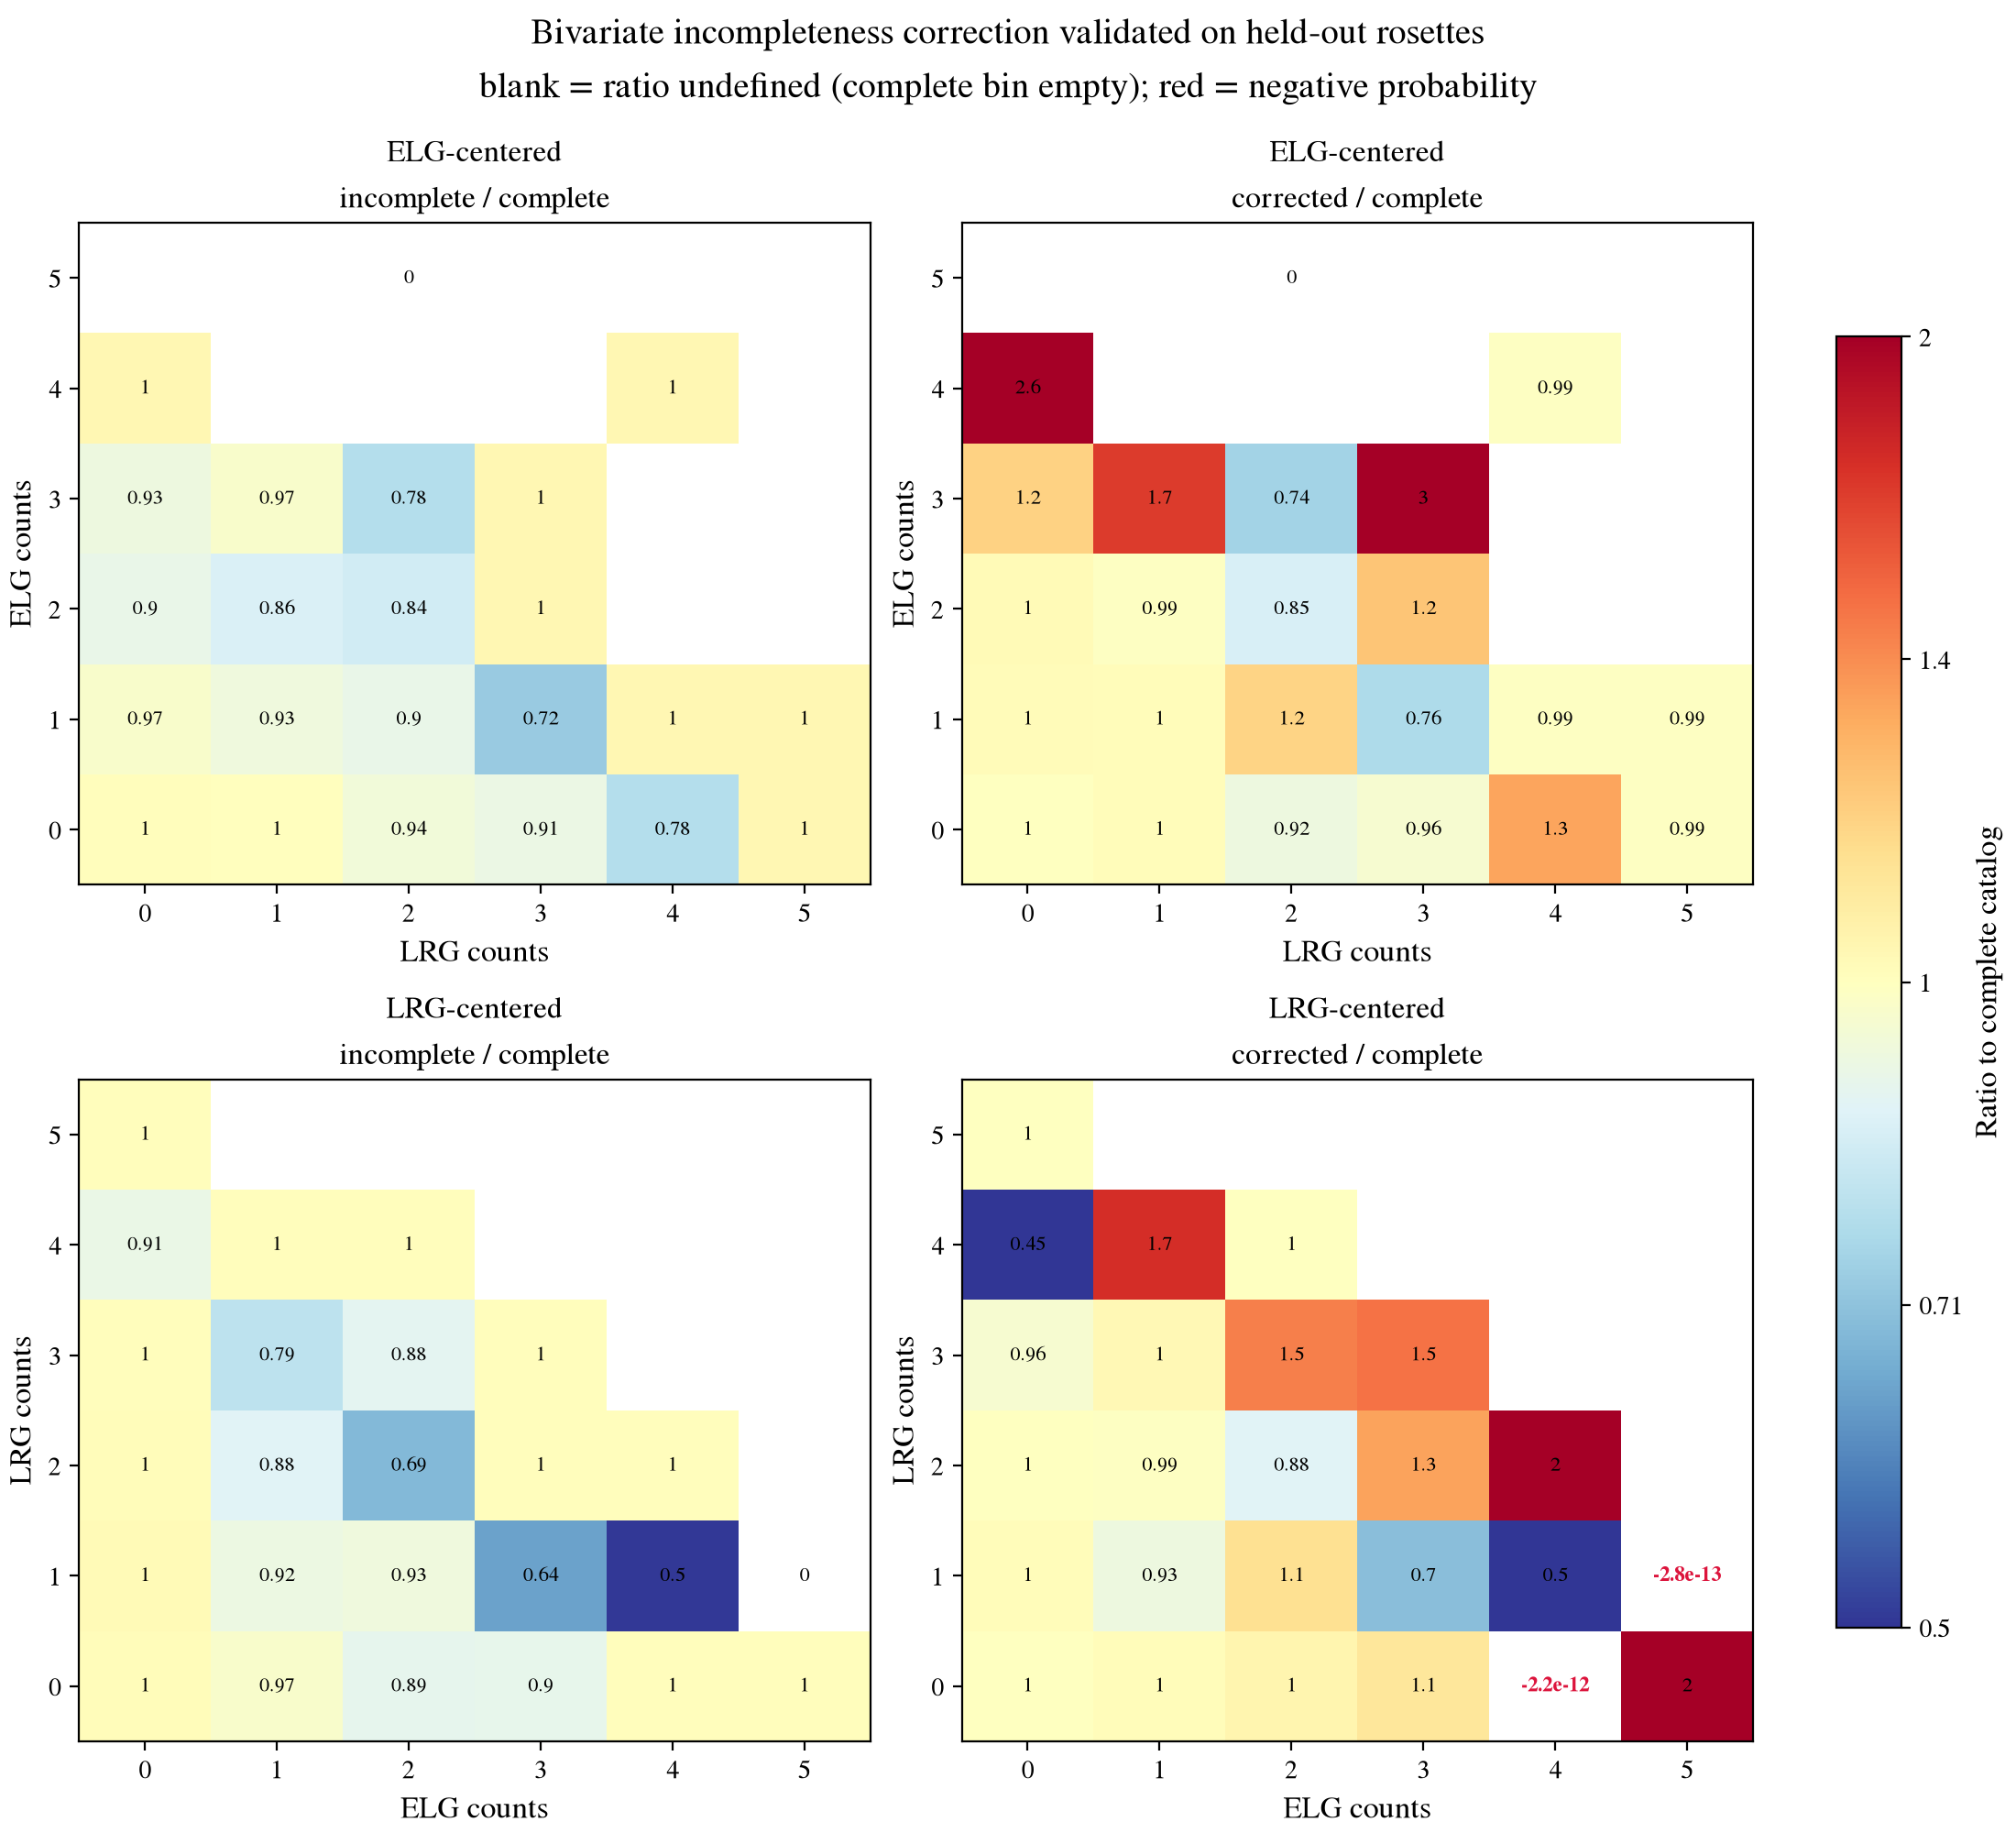

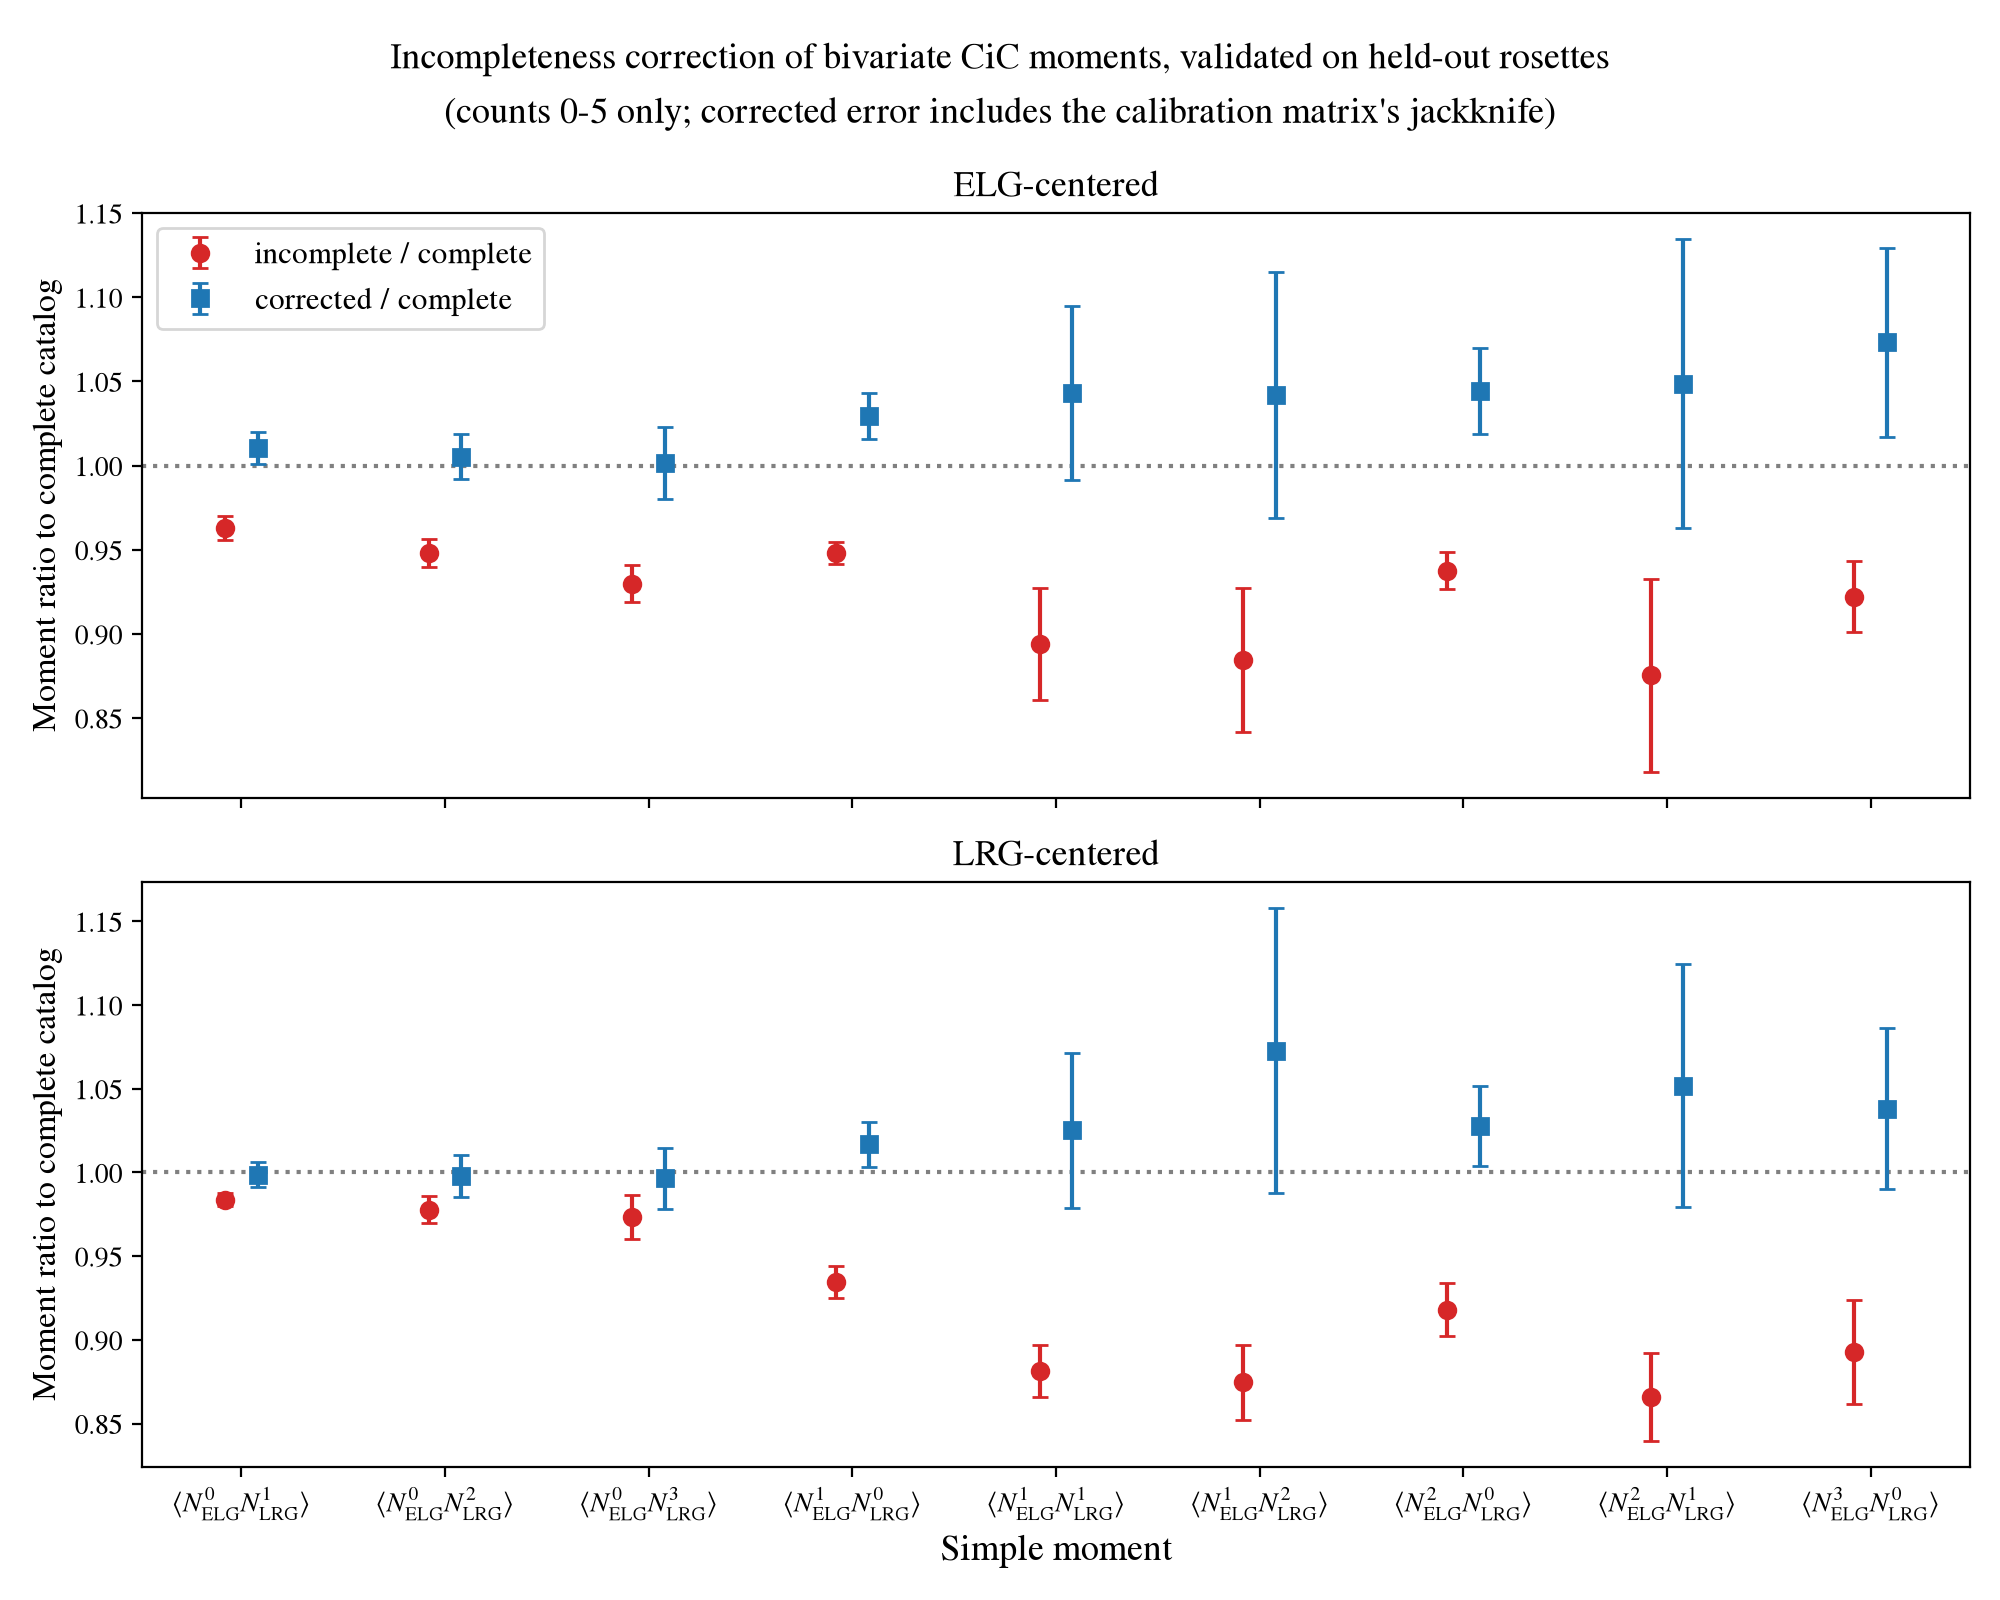

In [12]:
splitresult = TIC.run()
showFigures(splitresult)

splitresultswapped = TIC.run(swap=True)
showFigures(splitresultswapped)

## 2. Varying the diagonal padding

Run both tests for each padding. `plots = False` skips writing three figures per run. To see the full
figures for a single padding, call e.g. `showFigures(TIC.run(selftest = True, padding = 0.5))`;
non-default paddings get their own file names (`..._self_pad0.5.png`).

Set `QUIET = False` to see the full printed summary of every run.

In [18]:
PADDINGS = [0.25, 0.5, 1.0, 2.0, 5.0]
QUIET = True

def runQuietly(**kwargs):
    if not QUIET:
        return TIC.run(**kwargs)
    with contextlib.redirect_stdout(io.StringIO()):
        return TIC.run(**kwargs)

scan = {'self': {}, 'split': {}}
for padding in PADDINGS:
    scan['self'][padding] = runQuietly(selftest = True, padding = padding, plots = False)
    scan['split'][padding] = runQuietly(padding = padding, plots = False)
    print("padding %-5g done; rconds (self): %s" % (padding, ", ".join(
        "%.1e" % r for r in scan['self'][padding]['rconds'].values())))

/global/u1/c/crmiller/CiC/CiCPlot.py:18: RuntimeWarning: invalid value encountered in subtract
  deviations = replicates - fullvalue


padding 0.25  done; rconds (self): 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15
padding 0.5   done; rconds (self): 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15
padding 1     done; rconds (self): 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15
padding 2     done; rconds (self): 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15
padding 5     done; rconds (self): 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15, 1.0e-15


rosettes available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
calibrating on:     [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
testing on:         [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
diagonal padding:   0.5

choosing rcond within the calibration rosettes (1D):
  ELG counts around ELGs rcond = 1.000e-15  (split-sample RMS corrected/true - 1 = 0.0572; worst in scan 0.1510)
    NOTE: the optimum is at the low end of the scanned range. Either no regularization is needed (low end) or the range does not reach far enough -- widen RCONDVALUES and rerun to be sure.
  LRG counts ar

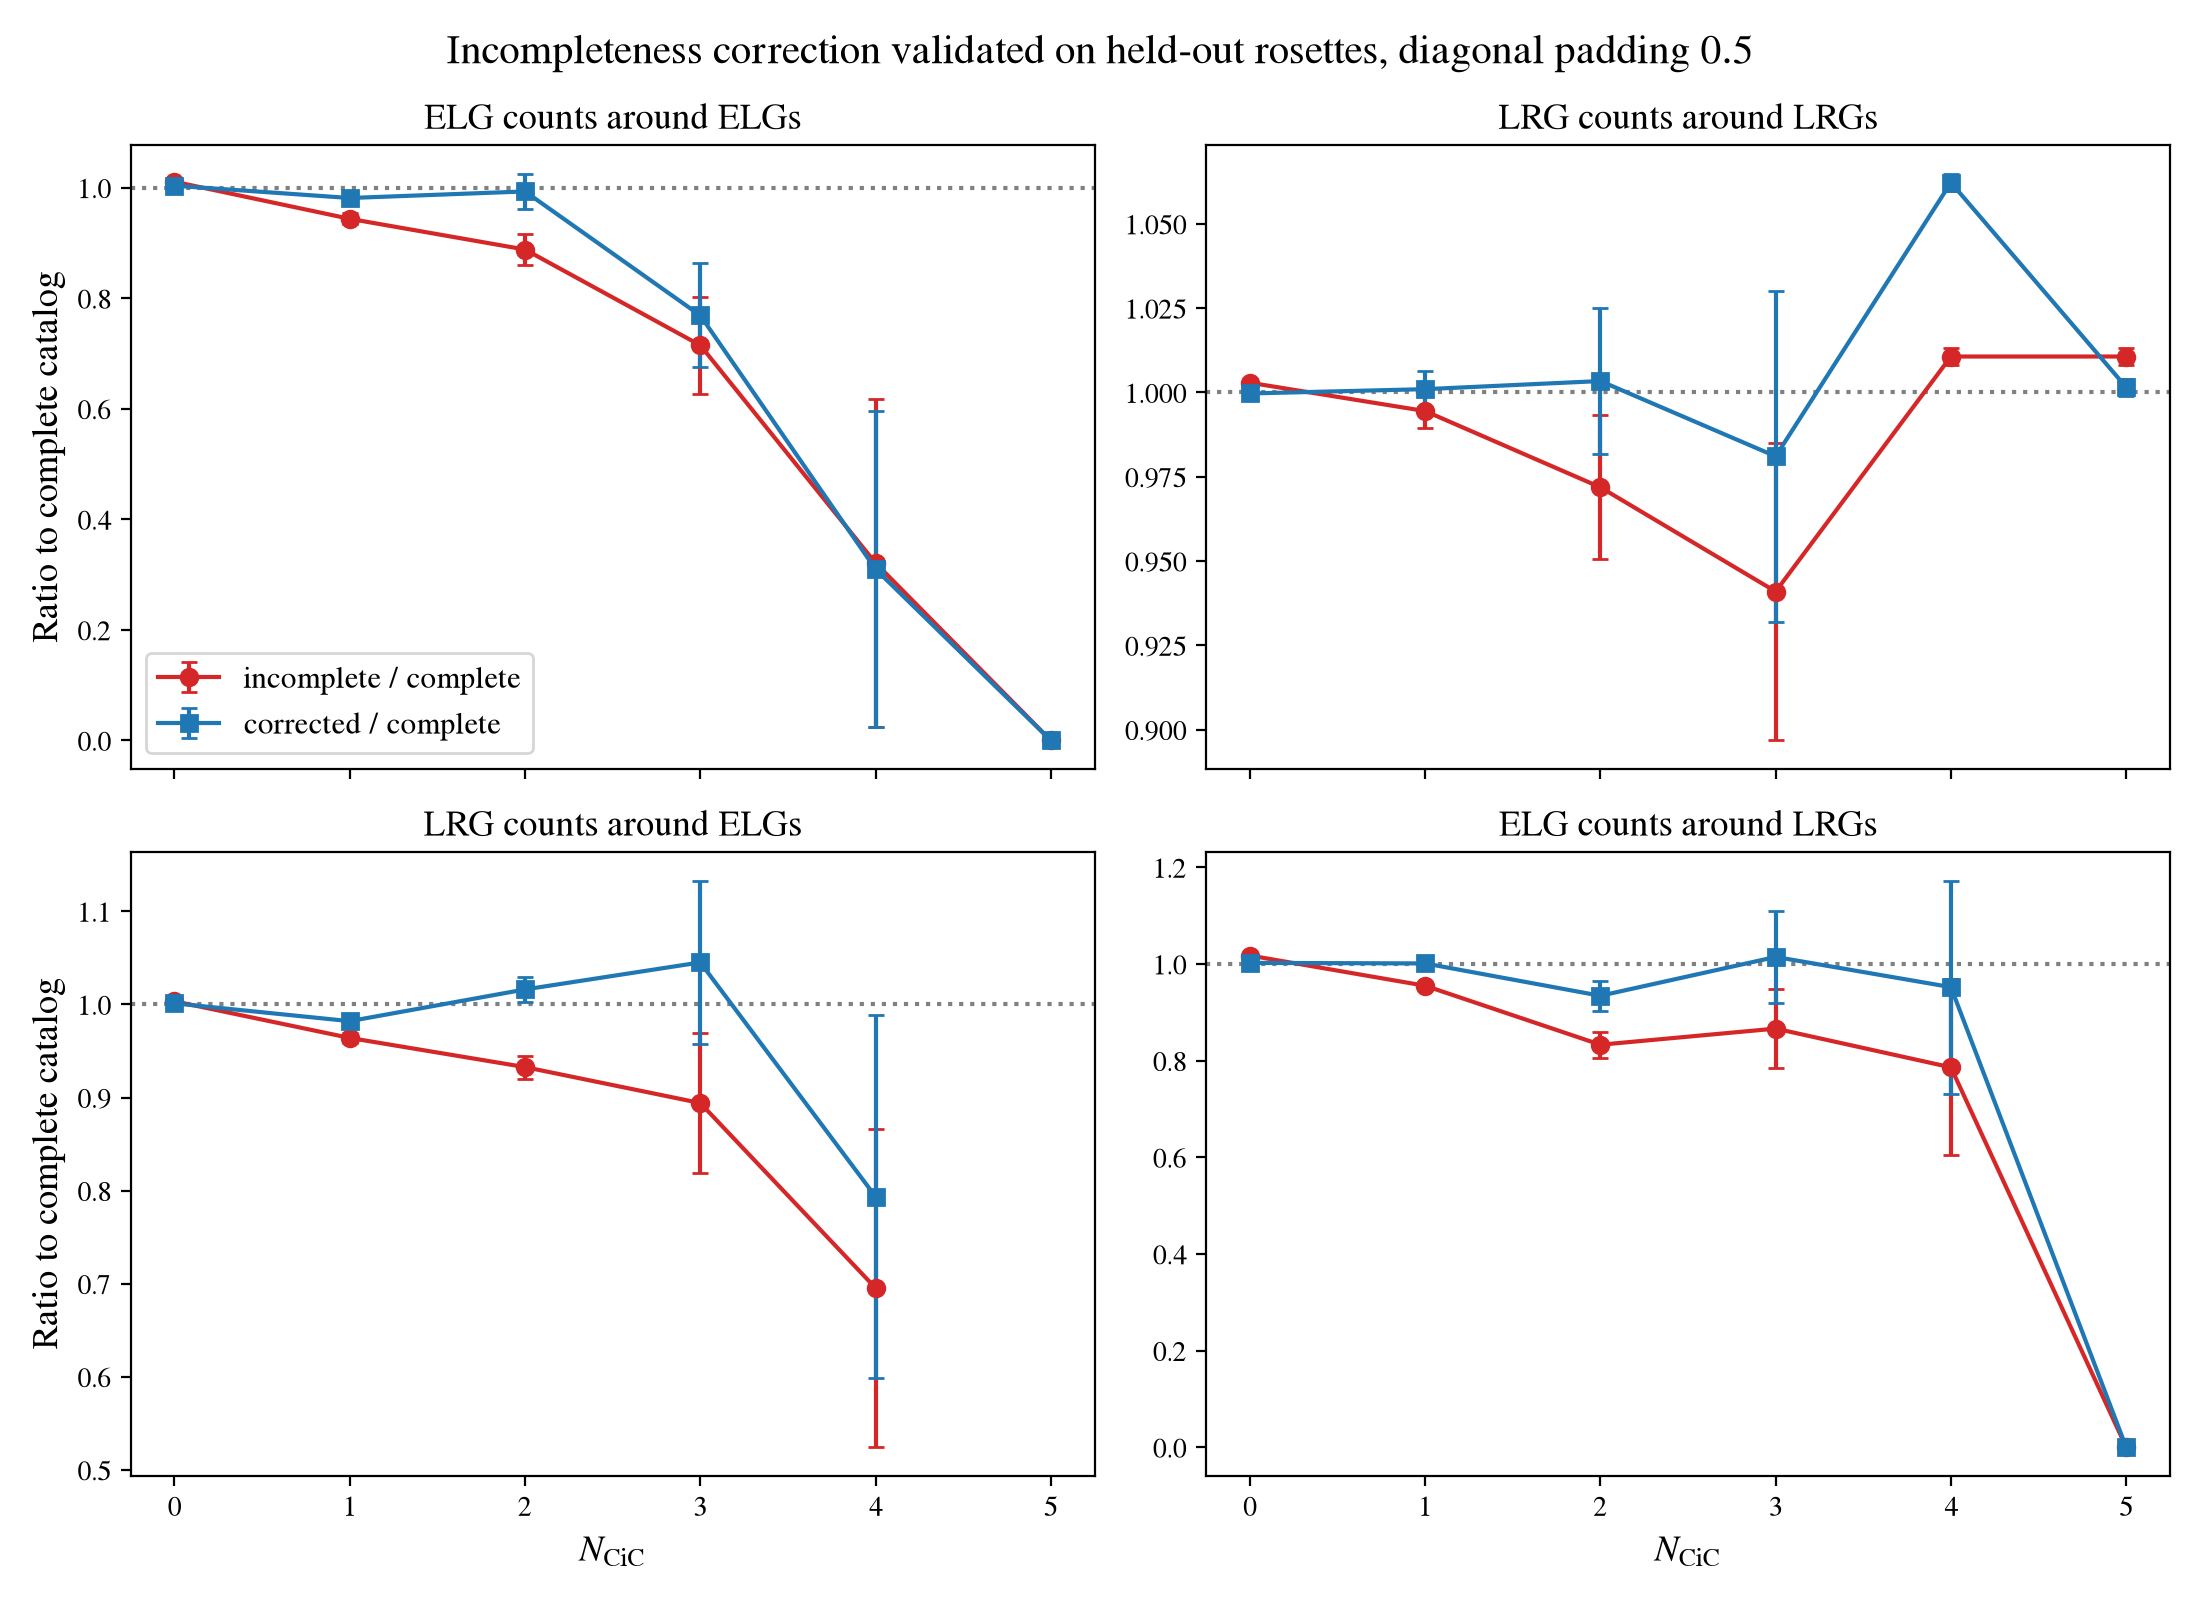

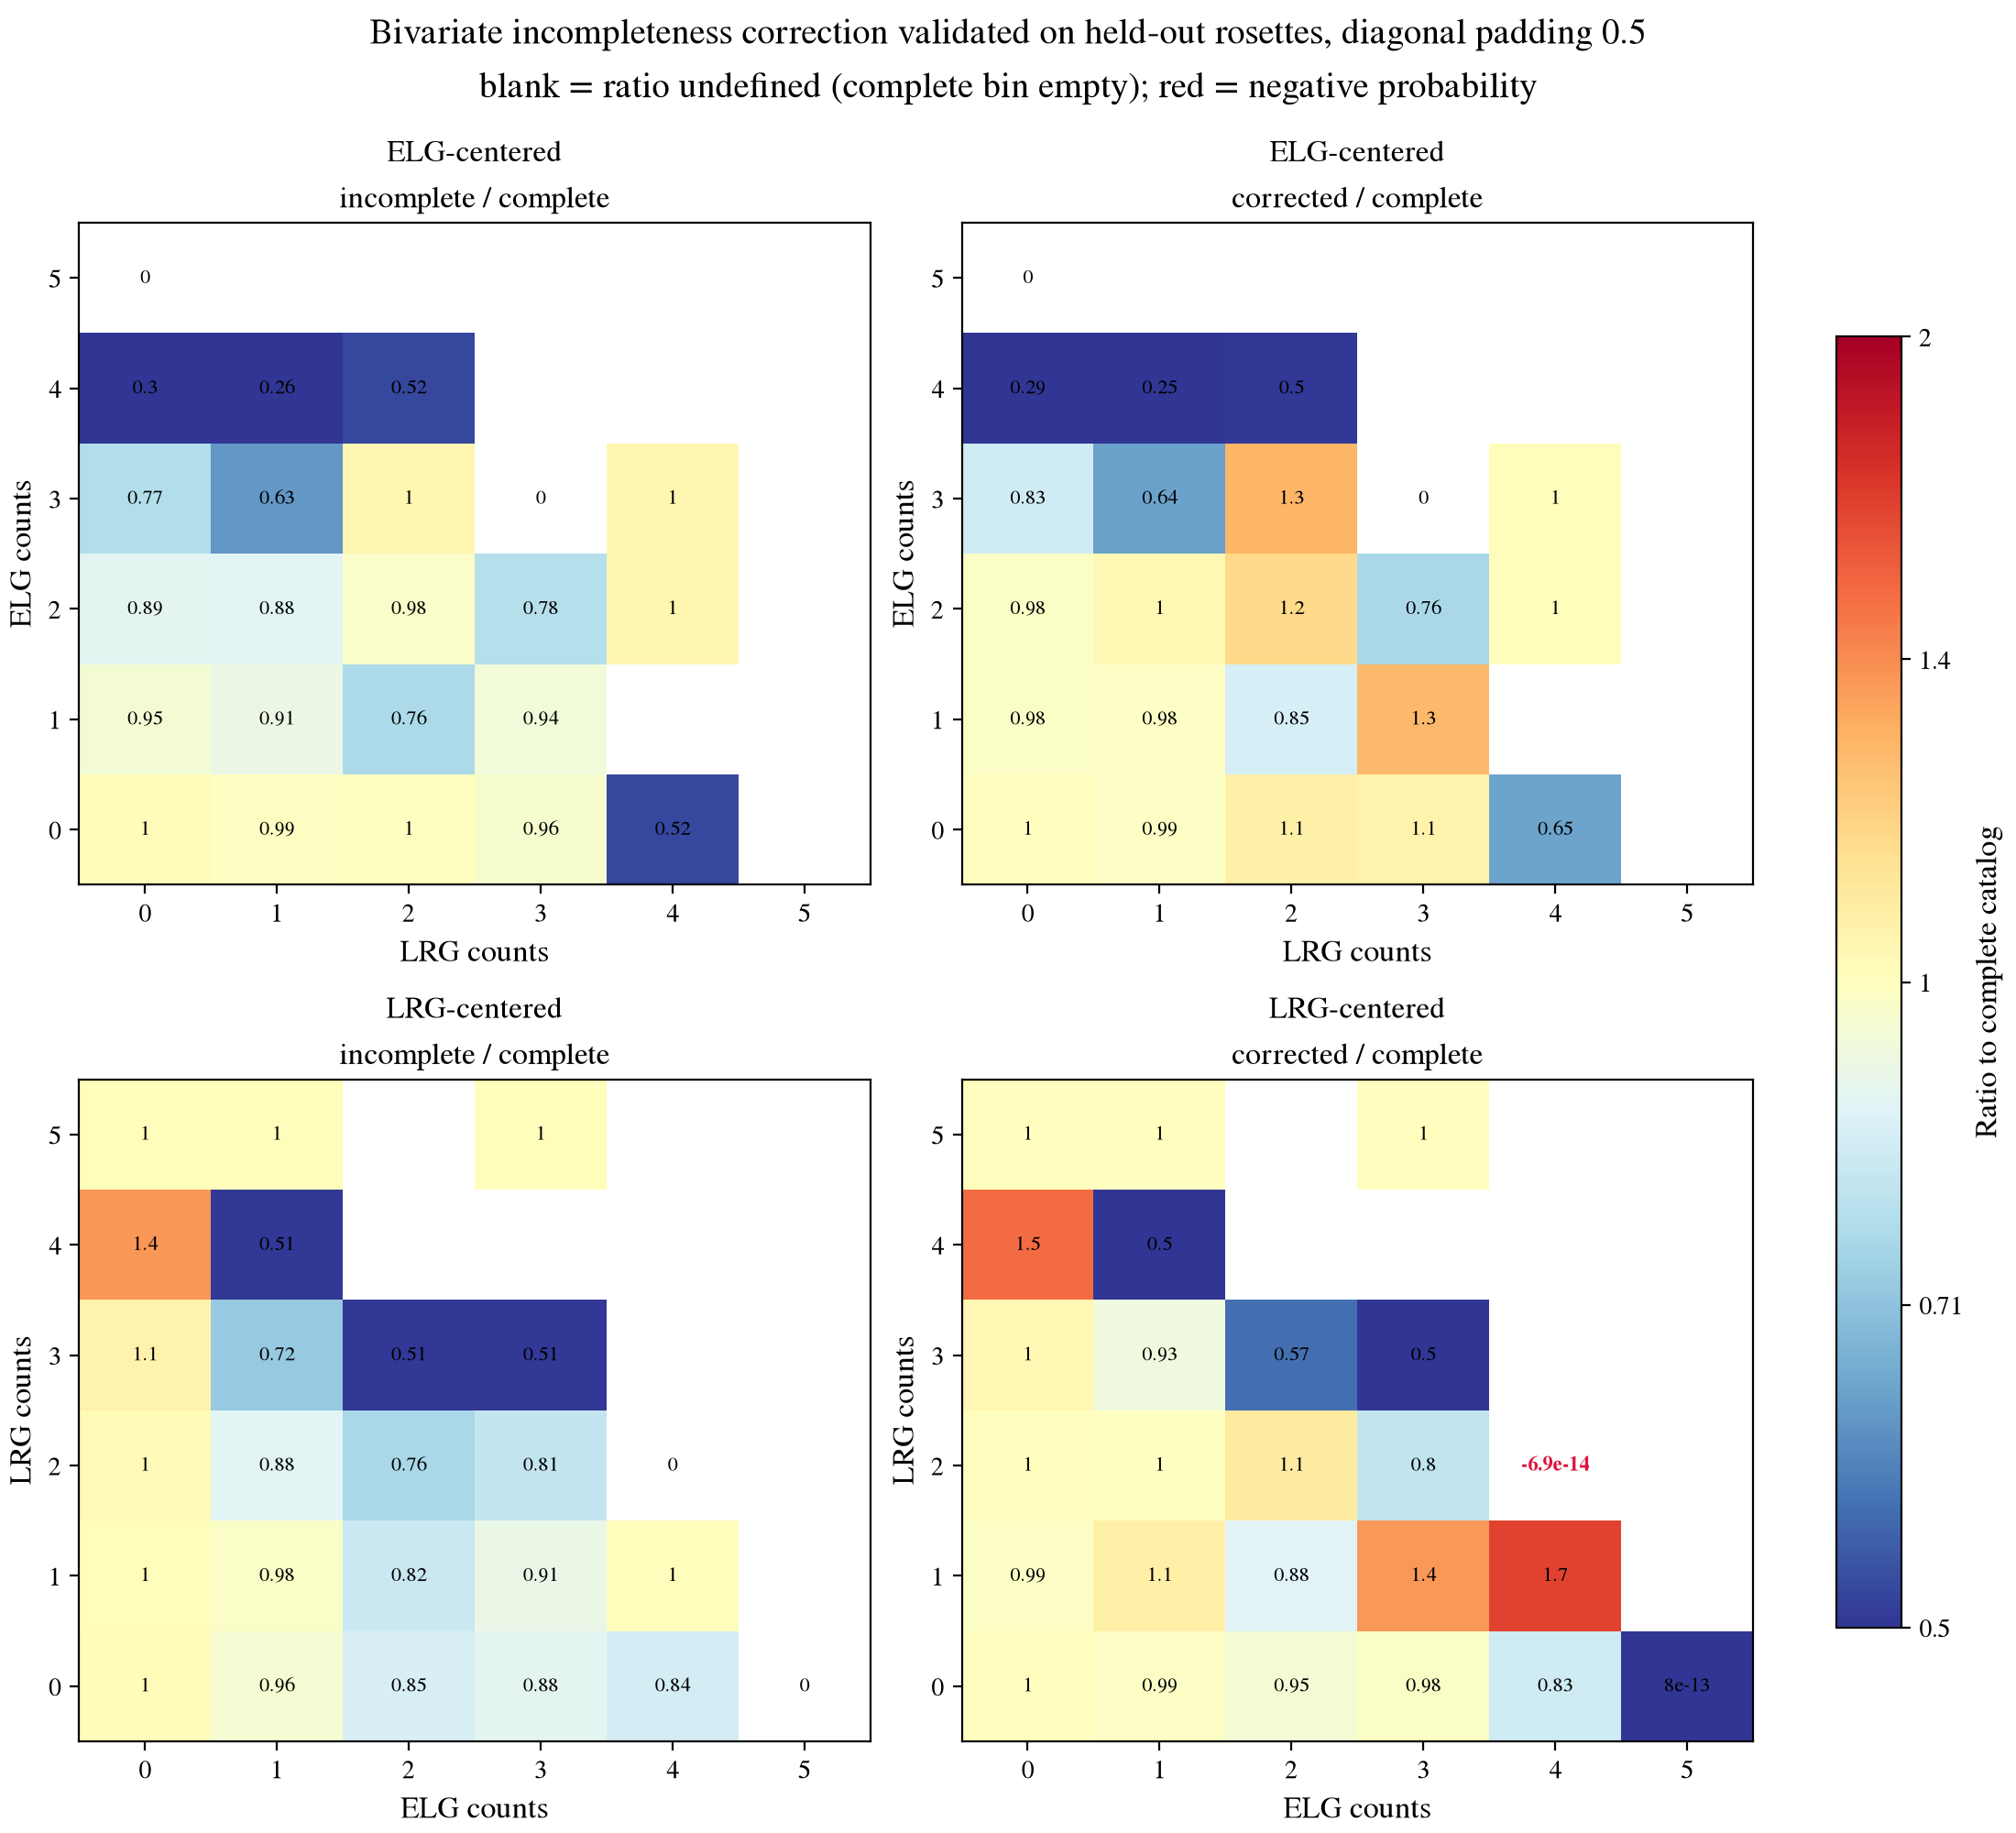

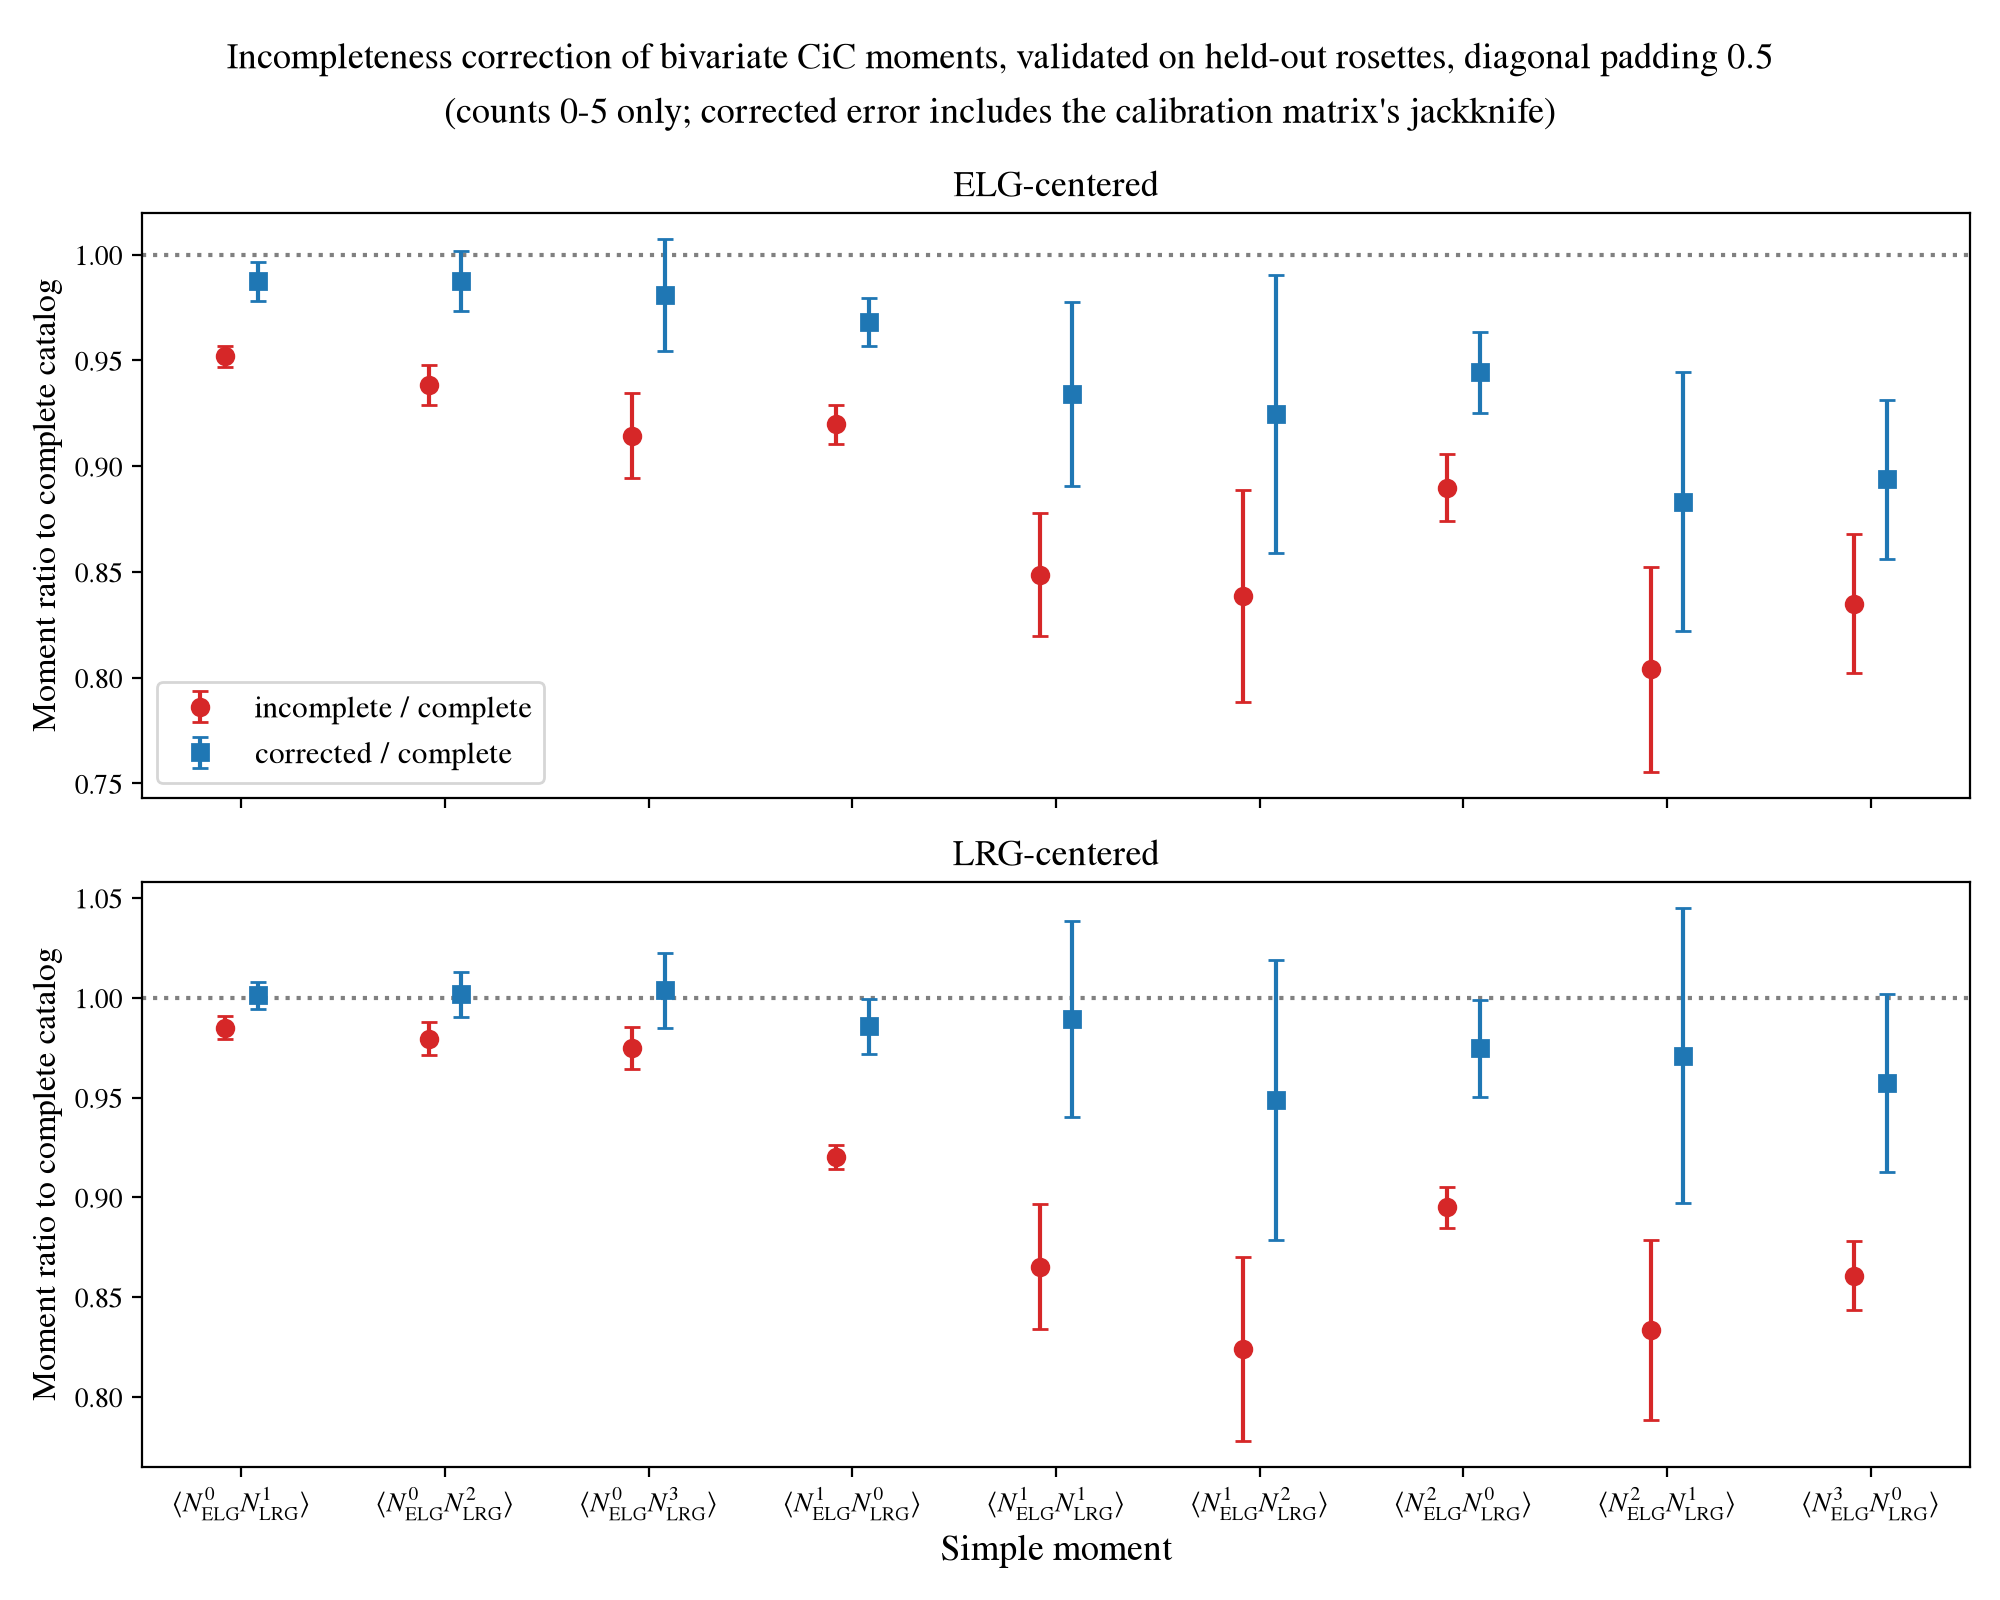

In [19]:
showFigures(TIC.run(selftest = False, padding = 0.5))

### Summary: RMS of the ratio from 1, vs padding

One panel per distribution (four 1D, two bivariate). Each panel shows the corrected ratio for the self-test
and the split-half test, with the uncorrected ratio (which does not depend on padding) as horizontal
lines for reference.

The sparse high-count bins dominate an RMS, so `MINOBJECTS` restricts it to bins holding at least that many
objects in the complete test catalog. Set it to 1 to include every non-empty bin.

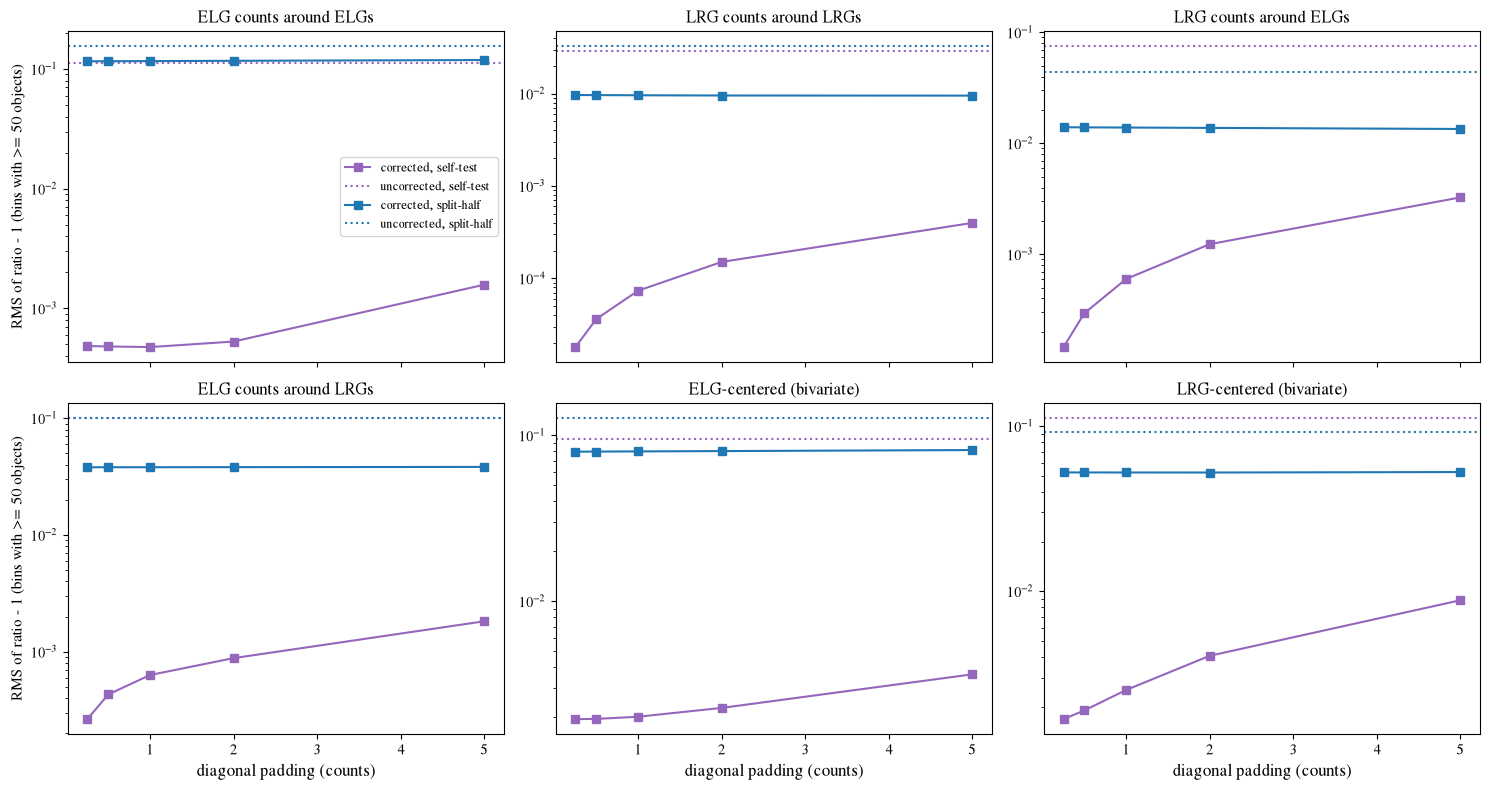

In [20]:
MINOBJECTS = 50

def rmsFromOne(ratio, completecounts, minobjects = MINOBJECTS):
    ratio = np.asarray(ratio)
    good = (np.asarray(completecounts) >= minobjects) & np.isfinite(ratio)
    return np.sqrt(np.mean((ratio[good] - 1)**2)) if np.any(good) else np.nan

def distributionEntries(result):
    # (name, uncorrected, uncorrectederr, corrected, correctederr, completecounts)
    return result['results1d'] + [(entry[0] + " (bivariate)",) + tuple(entry[1:])
                                  for entry in result['summaries2d']]

names = [entry[0] for entry in distributionEntries(scan['self'][PADDINGS[0]])]
fig, axes = plt.subplots(2, 3, figsize = (15, 8), sharex = True)
for index, (ax, name) in enumerate(zip(axes.ravel(), names)):
    for mode, color in [('self', 'tab:purple'), ('split', 'tab:blue')]:
        entries = [distributionEntries(scan[mode][p])[index] for p in PADDINGS]
        ax.plot(PADDINGS, [rmsFromOne(e[3], e[5]) for e in entries], marker = 's', color = color,
                label = 'corrected, %s' % ('self-test' if mode == 'self' else 'split-half'))
        ax.axhline(rmsFromOne(entries[0][1], entries[0][5]), color = color, linestyle = 'dotted',
                   label = 'uncorrected, %s' % ('self-test' if mode == 'self' else 'split-half'))
    ax.set_title(name, fontsize = 12)
    ax.set_yscale('log')
for ax in axes[1]:
    ax.set_xlabel("diagonal padding (counts)", fontsize = 12)
for ax in axes[:, 0]:
    ax.set_ylabel("RMS of ratio - 1 (bins with >= %d objects)" % MINOBJECTS, fontsize = 11)
axes[0, 0].legend(fontsize = 9)
fig.tight_layout()
plt.show()

### 1D corrected ratios for each padding

corrected / complete vs $N_\mathrm{CiC}$, one line per padding. Top block is the self-test (pure bias);
bottom block is the split-half test. Error bars are omitted for legibility; they are in the full figures.

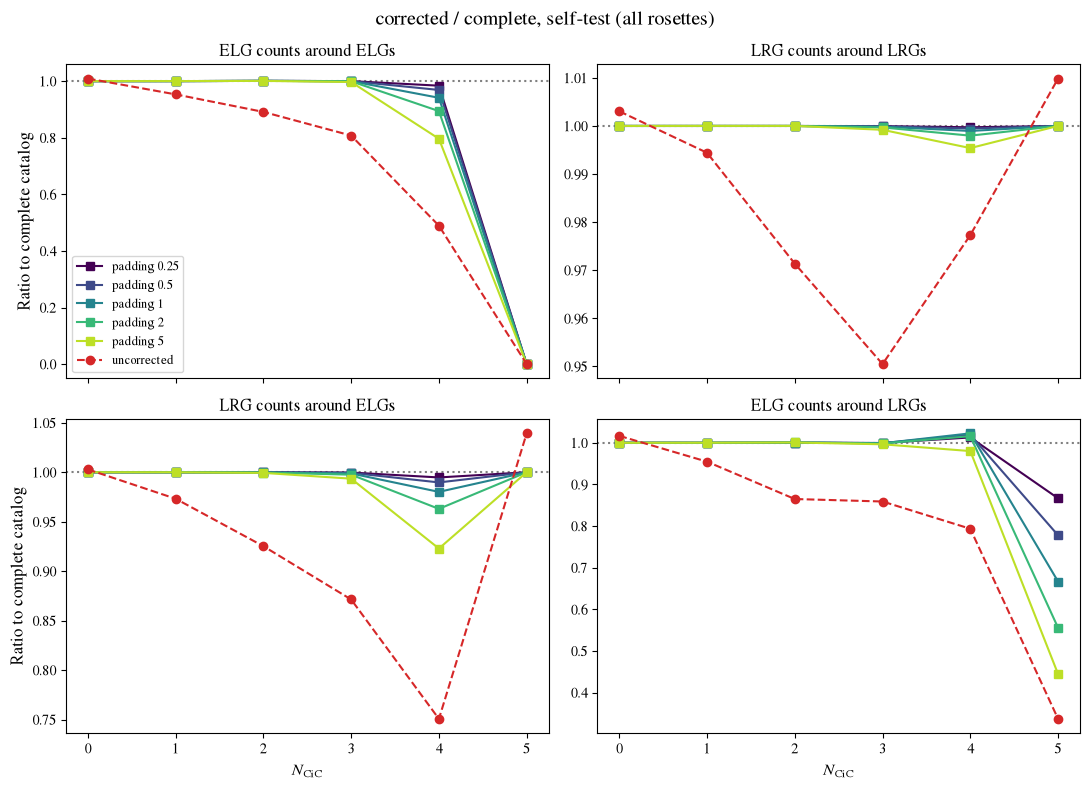

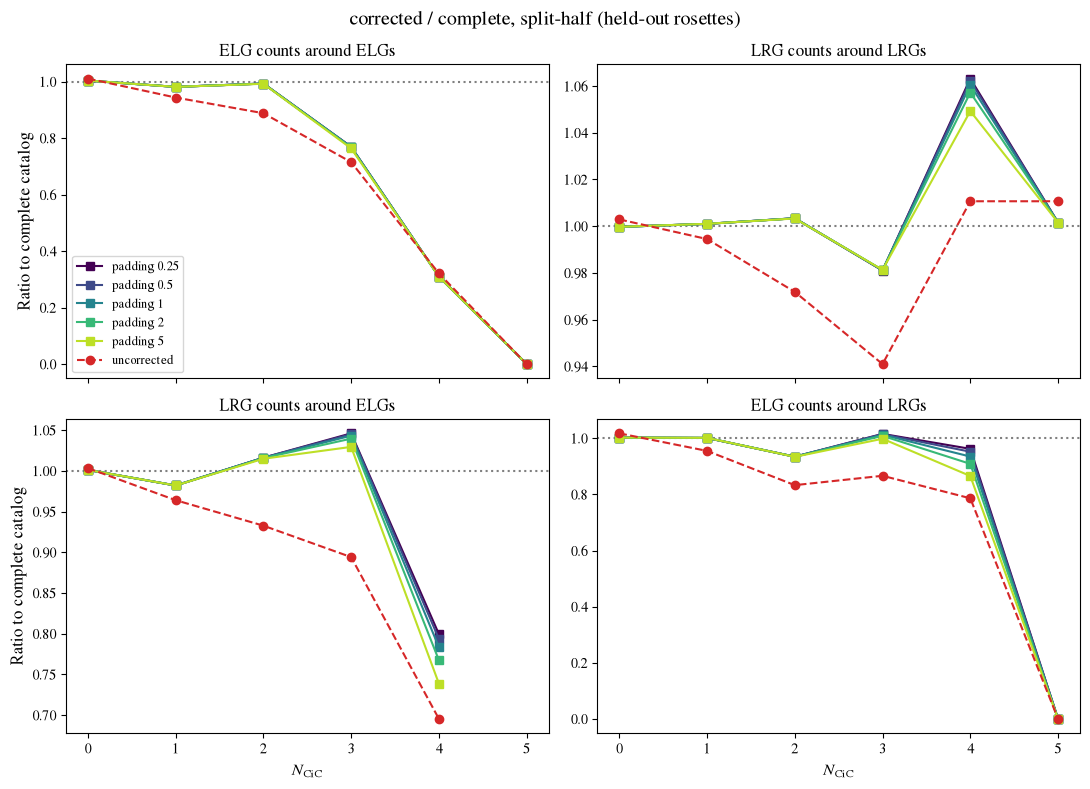

In [21]:
colors = plt.cm.viridis(np.linspace(0, 0.9, len(PADDINGS)))
ncic = np.arange(TIC.MAXCOUNTS + 1)
for mode, title in [('self', 'self-test (all rosettes)'), ('split', 'split-half (held-out rosettes)')]:
    fig, axes = plt.subplots(2, 2, figsize = (11, 8), sharex = True)
    for index, ax in enumerate(axes.ravel()):
        ax.axhline(1.0, color = 'gray', linestyle = 'dotted')
        for padding, color in zip(PADDINGS, colors):
            name, uncorrected, _, corrected, _, completecounts = scan[mode][padding]['results1d'][index]
            ax.plot(ncic, corrected, marker = 's', color = color, label = "padding %g" % padding)
        ax.plot(ncic, uncorrected, marker = 'o', color = 'tab:red', linestyle = 'dashed',
                label = 'uncorrected')
        ax.set_title(name, fontsize = 12)
        ax.set_xticks(ncic)
    for ax in axes[1]:
        ax.set_xlabel(r"$N_\mathrm{CiC}$", fontsize = 12)
    for ax in axes[:, 0]:
        ax.set_ylabel("Ratio to complete catalog", fontsize = 12)
    axes[0, 0].legend(fontsize = 9)
    fig.suptitle("corrected / complete, %s" % title, fontsize = 14)
    fig.tight_layout()
    plt.show()

### Moments of the bivariate distribution for each padding

corrected / complete for each simple moment $\langle N_\mathrm{ELG}^m N_\mathrm{LRG}^n\rangle$ (counts 0 to
`MAXCOUNTS` only). The split-half points carry their full (sample + incompleteness) error bars.

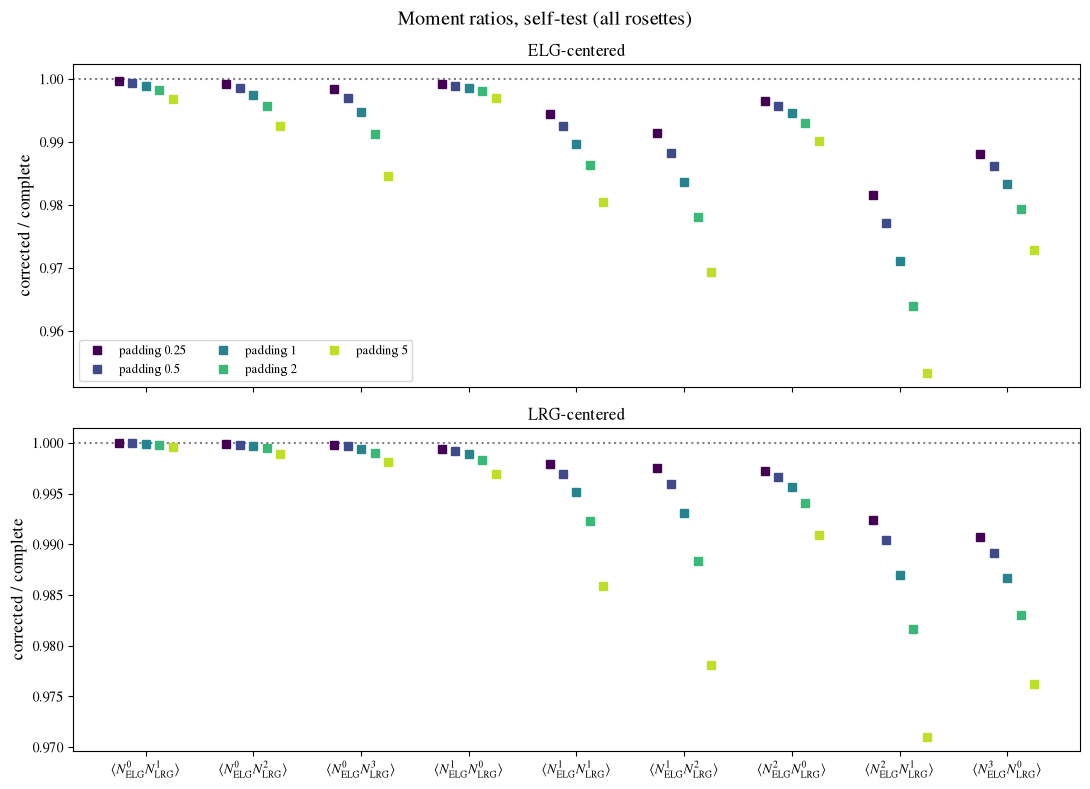

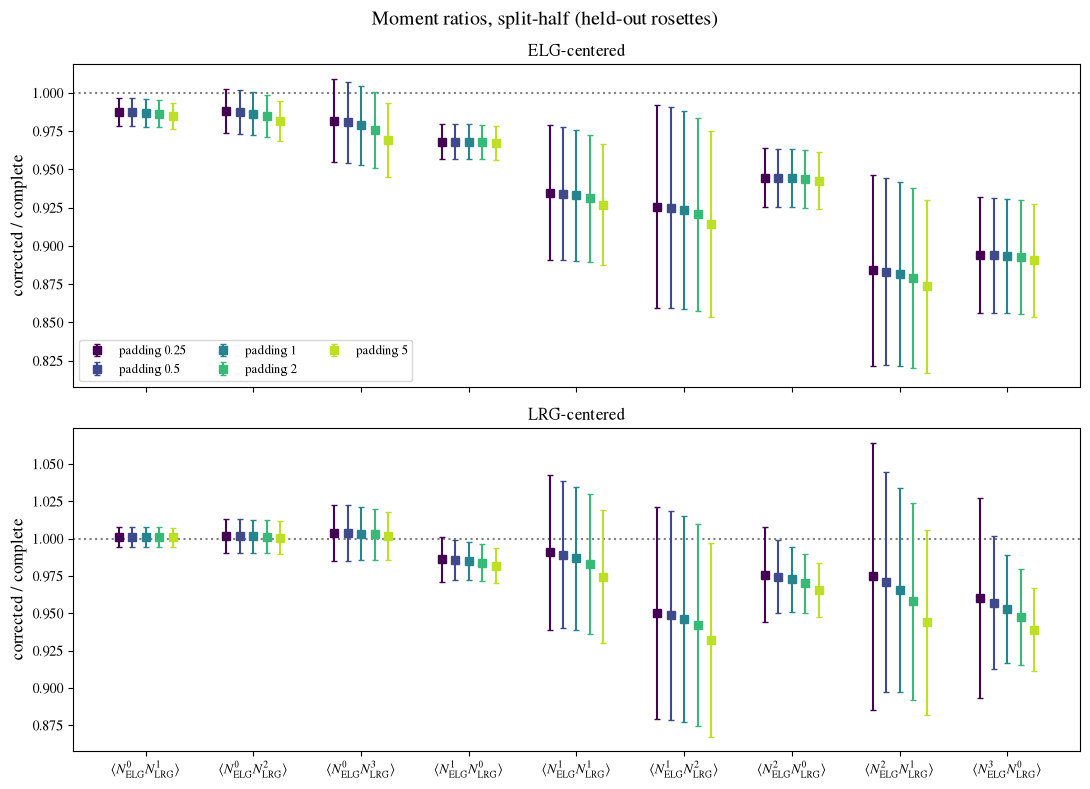

In [22]:
for mode, title in [('self', 'self-test (all rosettes)'), ('split', 'split-half (held-out rosettes)')]:
    fig, axes = plt.subplots(2, 1, figsize = (11, 8), sharex = True)
    for index, ax in enumerate(axes):
        ax.axhline(1.0, color = 'gray', linestyle = 'dotted')
        offsets = np.linspace(-0.25, 0.25, len(PADDINGS))
        for padding, color, offset in zip(PADDINGS, colors, offsets):
            name, moments = scan[mode][padding]['moments'][index]
            x = np.arange(len(moments['orders']))
            ax.errorbar(x + offset, moments['corrected'],
                        yerr = moments['correctederr'] if mode == 'split' else None,
                        marker = 's', linestyle = 'none', capsize = 2, color = color,
                        label = "padding %g" % padding)
        ax.set_title(name, fontsize = 12)
        ax.set_ylabel("corrected / complete", fontsize = 12)
        ax.set_xticks(x)
        ax.set_xticklabels([r"$\langle N_\mathrm{ELG}^{%d} N_\mathrm{LRG}^{%d}\rangle$" % tuple(order)
                            for order in moments['orders']], fontsize = 10)
    axes[0].legend(fontsize = 9, ncol = 3)
    fig.suptitle("Moment ratios, %s" % title, fontsize = 14)
    fig.tight_layout()
    plt.show()

### Separating padding bias from regularization bias

In the scan above, rcond is re-chosen for every padding, so the self-test bias mixes the two. Fixing rcond
to a negligible value (a one-element `rcondvalues`) leaves only the padding. So the padding-0 column should be
zero to rounding error (~1e-13), and each later column is the bias that amount of padding adds.

The one exception: a padding-0 entry can be large if some true bin has **no** objects observed in its own bin
(an empty diagonal cell). The matrix is then singular, and nothing recovers that bin exactly. Avoiding exactly
this is the purpose of the padding.

In [ ]:
FIXEDRCOND = [1e-15]
fixed = {padding: runQuietly(selftest = True, padding = padding, plots = False, rcondvalues = FIXEDRCOND)
         for padding in PADDINGS}

print("self-test, rcond fixed at %g: max |corrected/complete - 1| over bins with >= %d objects"
      % (FIXEDRCOND[0], MINOBJECTS))
print("%-32s" % "" + "".join("%10s" % ("pad %g" % p) for p in PADDINGS))
for index, name in enumerate(names):
    row = []
    for padding in PADDINGS:
        entry = distributionEntries(fixed[padding])[index]
        ratio, counts = np.asarray(entry[3]), np.asarray(entry[5])
        good = (counts >= MINOBJECTS) & np.isfinite(ratio)
        row.append(np.max(np.abs(ratio[good] - 1)) if np.any(good) else np.nan)
    print("%-32s" % name + "".join("%10.2e" % value for value in row))

### Note: counts above `MAXCOUNTS`

Fiber assignment only lowers counts, so an object whose true count is above `MAXCOUNTS` can be observed inside
the range. If the matrices had rows only for 0..`MAXCOUNTS`, such objects would be in the observed histogram but in
no row, and the inversion would push them into the in-range true bins. The error would start in the top bin and
spread down through the inverse.

So every count axis, in the histograms and in the matrices, ends in an **overflow state** holding all counts above
`MAXCOUNTS`. Every object then belongs to some row. The overflow state is used only to correct the in-range bins:
after correcting, it is dropped and the in-range bins are renormalized. Nothing in these plots, tables or moments
includes it.

All histograms use half-integer edges, so the bin labelled `MAXCOUNTS` holds exactly that count.